# IMDB 影评情感二分类 —— 两种分词方式 × 三种文本表示方法

对比两种分词方式（词级 / BPE 子词）与三种文本表示方法（Embedding+平均池化、
Embedding+RNN、Embedding+LSTM），共 6 组模型，在 IMDB 影评上做情感二分类。
- 分词方式一：词级 —— 正则清洗标点 + Counter 词频统计，取高频 20000 词建词典。
- 分词方式二：子词级 —— 用 subword-nmt 工具学习 BPE（字节对编码）合并规则并分词，
词表约 8300 个子词，未登录词可被拆成已见子词，缓解 OOV。
脚本包含以下内容：
0. 导入所有需要的库 与 路径约定
1. HuggingFace datasets 库加载 IMDB 影评数据集（本地缓存，避免重复下载）
--- 分词方式一：词级 ---
2. 文本清洗与词典构建（正则清洗 + Counter 词频统计 + 特殊符号占位，词表 20000）
3. 单词数分布可视化 —— 决定序列最大长度 max_length
--- 分词方式二：BPE 子词 ---
4. 生成纯文本文件 imdb_train.txt / imdb_test.txt（去除换行，一行一条）
5. 使用 subword-nmt 在训练集上学习 BPE 子词分词规则与词表（若已存在则跳过）
6. 使用学习到的 BPE 规则对训练/测试文本分词（若已存在则跳过）
7. 基于 BPE 词表构建 subword 词典与反向词典
8. 读取 BPE 分词后的文本
9. 每样本子词数分布可视化
--- 共享：Tokenizer 与数据管道 ---
10. Tokenizer 分词器类（encode/decode，BOS/EOS/PAD/OOV，支持前置/后置 padding）
11. 实例化两个 Tokenizer（词级 / BPE）并测试
12. 自定义 IMDBDataset Dataset 类 + create_collate_fn 组 batch 回调
13. 为两种分词构建 Dataset 与 DataLoader（池化用句尾 padding，循环模型用句首 padding）
14. 批量验证
--- 共享：训练组件与模型 ---
15. Trainer 通用训练器类（二分类，BCEWithLogitsLoss，损失与准确率可视化）
16. nn.LSTM 层基础 —— 单层单向 / 双向 / 双层 三种配置的参数与输出形状对比
17. 模型一：Embedding + AdaptiveAvgPool1d + 全连接（子词袋式，不建模顺序）
18. 模型二：Embedding + RNN + 全连接（循环网络建模顺序，支持双向/多层扩展）
19. 模型三：Embedding + LSTM + 全连接（LSTM 建模顺序，含细胞状态缓解梯度消失）
--- 词级（分词方式一）训练 ---
20. 词级三模型实例化、前向传播验证与参数量统计
21. 通用训练辅助函数 train_single_model
22. 训练词级三个模型并绘制训练曲线
--- BPE（分词方式二）训练 ---
23. BPE 三模型实例化、前向传播验证与参数量统计
24. 训练 BPE 三个模型并绘制训练曲线
--- 总结 ---
25. 六模型对比总结（分词方式 × 文本表示）
依赖安装（首次运行前）：
pip install datasets subword-nmt

## 0. 导入所有需要的库 与 路径约定

In [74]:
import os  # 操作系统接口，用于路径拼接、缓存目录判断
import re  # 正则表达式库，用于词级文本清洗
import subprocess  # 子进程接口：调用 subword-nmt 命令行工具
from collections import Counter  # 计数器类，用于词级词频统计
import numpy as np  # 数值计算库，用于数组化文本与标签
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Embedding、RNN、LSTM、Linear、AdaptiveAvgPool1d 等层
import torch.optim as optim  # 优化器模块，提供 Adam 等
from torch.utils.data import Dataset, DataLoader  # Dataset: 自定义数据集基类；DataLoader: 批量加载器
import matplotlib.pyplot as plt  # 绘图库，用于训练曲线与直方图可视化
# 注意：datasets 库在 import 时就会读取离线相关环境变量，
#       因此把它留到第 1 节设置好缓存/离线策略之后再导入（见下）。

In [75]:
# 路径约定：
# 本脚本位于仓库根目录，BPE 相关的数据文件（imdb_*.txt、imdb_bpe_*）统一放在
# data/ 目录，因此用 ROOT_DIR/DATA_DIR 前缀定位，避免依赖运行时当前目录。
try:
    # 以 .py 脚本运行时：用脚本所在目录定位仓库根目录
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # 以 Jupyter notebook 运行时：没有 __file__ 变量，退回用当前工作目录
    # （从仓库根目录启动 Jupyter 时，当前工作目录即仓库根目录）
    ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, 'data')  # BPE 数据所在目录

## 1. 数据准备 —— 加载 IMDB 影评数据集（两种分词共用）
IMDB 是一个经典的英文影评情感二分类数据集：
  - 训练集 25000 条影评（正面 12500 / 负面 12500）
  - 测试集 25000 条影评（正面 12500 / 负面 12500）
  - 每条样本: 一段文本（英文影评）+ 一个标签（0=负面, 1=正面）

In [76]:
# 指定数据缓存目录：首次加载会把数据集下载到这里，之后从本地读取，避免重复下载
cache_dir = os.path.join(ROOT_DIR, 'data', 'hf_cache')  # 缓存目录（与同级其它脚本共用）

In [77]:
# 检查本地缓存中是否已存在 IMDB 数据集（新版本 datasets 库用 'namespace/name' 格式）
imdb_cache_dir = os.path.join(cache_dir, 'stanfordnlp___imdb')  # 本地缓存中的实际目录名（含数据集版本子目录）
if (os.path.exists(imdb_cache_dir) and  # 缓存目录存在
        os.listdir(imdb_cache_dir)):  # 且目录非空（说明已下载过数据文件）
    print("检测到本地 IMDB 缓存，直接从缓存加载...")  # 提示直接使用本地缓存
    # 已有缓存时开启离线模式：让 datasets 库不再联网校验/更新元数据，
    # 否则无网环境下会因超时重试而卡住（WinError 10060）。
    os.environ['HF_HUB_OFFLINE'] = '1'  # 关闭 HuggingFace Hub 联网请求
    os.environ['HF_DATASETS_OFFLINE'] = '1'  # 关闭 datasets 库的联网校验
else:  # 本地没有缓存
    print("本地无 IMDB 缓存，首次加载需要联网下载（之后会存入 cache_dir）")  # 提示需要下载

# 离线模式设置完成后再导入 datasets 库，确保上面设置的离线环境变量被它读取到
from datasets import load_dataset  # HuggingFace datasets 库，用于加载 IMDB 数据集

检测到本地 IMDB 缓存，直接从缓存加载...


In [78]:
# load_dataset: 下载（或从缓存读取）并解析 IMDB 数据集，返回 DatasetDict（含 'train'/'test' 两个 split）
dataset = load_dataset('stanfordnlp/imdb', cache_dir=cache_dir)

Using the latest cached version of the dataset since stanfordnlp/imdb couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'plain_text' at /AIT/data/hf_cache/stanfordnlp___imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Tue Aug  4 07:49:55 2026).


In [79]:
print(type(dataset))  # 打印数据集类型: <class 'datasets.dataset_dict.DatasetDict'>
print(type(dataset['train']['text']))  # 打印训练集 text 列的类型: <class 'list'>

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Column'>


In [80]:
# 将训练集/测试集的内容与标签分别提取为 numpy 数组
# dataset['train']['text'] 返回该 split 下所有样本的 text 字段（Python list）
train_texts = np.array(dataset['train']['text'])  # 原始训练集影评文本数组 (25000,) —— 保留原样供两种分词使用
train_labels = np.array(dataset['train']['label'])  # 训练集标签数组 (25000,)，元素为 0/1
test_texts = np.array(dataset['test']['text'])  # 原始测试集影评文本数组 (25000,) —— 保留原样供两种分词使用
test_labels = np.array(dataset['test']['label'])  # 测试集标签数组 (25000,)

In [81]:
# 打印一条样本预览，了解数据格式
print("\n========== 样本预览 ==========")
print("训练集第 1 条影评开头:", train_texts[0][:200], "...")  # 仅打印前 200 字符避免刷屏
print("训练集文本 shape:", train_texts.shape)  # (25000,)
print("训练集标签取值:", np.unique(train_labels))  # array([0, 1])，二分类标签


========== 样本预览 ==========
训练集第 1 条影评开头: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev ...
训练集文本 shape: (25000,)
训练集标签取值: [0 1]


In [82]:
# 统计类别分布，确认数据集均衡
unique, counts = np.unique(train_labels, return_counts=True)  # 统计每个标签出现的次数
for label, count in zip(unique, counts):  # 遍历每个类别
    print(f"训练集类别 {label} 的数目: {count}")  # 应各为 12500，均衡分布

训练集类别 0 的数目: 12500
训练集类别 1 的数目: 12500


## 2. 分词方式一：词级 —— 文本清洗与词典构建
原始影评中含有标点（逗号、句号、HTML 的 <br /> 标签等），会影响分词。
我们先把标点替换为空格，再按空白字符切分成单词，最后统计词频构建词典。
词级分词把"一个单词"当作最小单元，词表取语料中最高频的 20000 个词，
词典外的词一律映射为 <OOV>（未登录词）。

In [83]:
def clean_text(text):
    """
    文本清洗函数 —— 去掉标点、合并连续空白

    参数:
        text: 原始影评字符串
    返回:
        清洗后的字符串（单词之间用单个空格分隔）
    """
    text = text.replace(',', ' ').replace('.', ' ')  # 将逗号、句号替换为空格（它们不携带情感信息）
    text = re.sub(r'\s+', ' ', text)  # 用正则把连续空白字符（空格/换行/<br/>）压缩为单个空格
    return text.strip()  # 去掉首尾空白后返回

# 对训练/测试文本分别清洗，得到"词级"用的文本（与 BPE 分词路径互不影响）
train_texts_word = np.array([clean_text(t) for t in train_texts])  # 逐个训练样本清洗
test_texts_word = np.array([clean_text(t) for t in test_texts])  # 逐个测试样本清洗

### 分词：把每句影评切成单词列表，再统一收集

In [84]:
all_words = []  # 收集训练集所有单词的列表（允许重复，用于统计词频）
for text in train_texts_word:  # 遍历每条清洗后的影评
    all_words.extend(text.split())  # split() 不带参数：按所有空白字符切分，得到该影评的单词列表

### 统计词频并构建词典

In [85]:
word_counts = Counter(all_words)  # 统计每个单词在训练集中出现的次数

In [86]:
# 限制词典大小：只保留出现频率最高的前 (max_vocab_size - 4) 个词，其余词一律视为未登录词
max_vocab_size = 20000  # 词典总大小（含 4 个特殊符号）
# 词典中预留 4 个特殊符号的固定 ID：
#   0  → <PAD>  填充符，用于把 batch 内不同长度的序列补齐到等长
#   1  → <OOV>  未登录词（Out Of Vocabulary），出现在词典之外的词统一映射为它
#   2  → <BOS>  句子开始符（Beginning Of Sentence）
#   3  → <EOS>  句子结束符（End Of Sentence）
vocab_word = {'<PAD>': 0, '<OOV>': 1, '<BOS>': 2, '<EOS>': 3}  # 初始化词级词典，先放入特殊符号

In [87]:
# 选出出现频率最高的 (max_vocab_size - 4) 个词，按词频从高到低分配 ID（从 4 开始）
most_common_words = word_counts.most_common(max_vocab_size - 4)  # 返回 [(单词, 次数), ...]，已按次数降序
start = 4  # 普通词的 ID 从 4 开始（0~3 已被特殊符号占用）
for idx, (word, count) in enumerate(most_common_words, start=start):  # enumerate 从 start=4 开始编号
    vocab_word[word] = idx  # 将单词映射为对应的整数 ID

print(f"词级词典大小: {len(vocab_word)}")  # 应输出 20000（4 个特殊符号 + 19996 个高频词）

词级词典大小: 20000


### 构建 ID 到 word 的反向词典，便于调试时把 ID 序列还原成文本

In [88]:
id2word_word = {idx: word for word, idx in vocab_word.items()}  # 反转字典: {ID: 单词}
for i in range(10):  # 打印前 10 个 ID 对应的词，检查词典是否正确
    print(f"{i}: {id2word_word[i]}")  # 0:<PAD> 1:<OOV> 2:<BOS> 3:<EOS> 4:the 5:a 6:and ...

0: <PAD>
1: <OOV>
2: <BOS>
3: <EOS>
4: the
5: a
6: and
7: of
8: to
9: is


## 3. 词级 —— 单词数分布可视化（决定 max_length）

In [89]:
# 统计每个样本的单词数量（清洗后按空格切分的长度）
sample_word_counts = [len(text.split()) for text in train_texts_word]  # 每条影评的单词个数

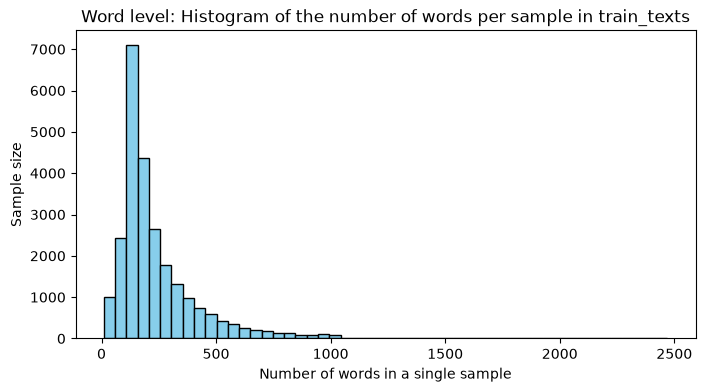

In [90]:
plt.figure(figsize=(8, 4))  # 创建 8×4 英寸的画布
plt.hist(sample_word_counts, bins=50, color='skyblue', edgecolor='black')  # 直方图: 50 个区间
plt.xlabel('Number of words in a single sample')  # 横轴: 每条影评包含的单词个数
plt.ylabel('Sample size')  # 纵轴: 落在该区间的样本数量
plt.title('Word level: Histogram of the number of words per sample in train_texts')  # 图表标题
plt.show()  # 显示图像

In [91]:
# 从直方图可以看到大多数影评集中在几百个词以内，
# 因此后续 Tokenizer 设 max_length=500：超过 500 词截断，不足则 padding 补齐。

## 4. 分词方式二：BPE 子词 —— 生成纯文本文件
BPE 工具（subword-nmt）的输入是"一行一条样本"的纯文本文件。
这里去掉每条影评内部的换行符，保证一条影评只占一行。

In [92]:
train_txt_path = os.path.join(DATA_DIR, 'imdb_train.txt')  # 训练集纯文本路径
test_txt_path = os.path.join(DATA_DIR, 'imdb_test.txt')  # 测试集纯文本路径

In [93]:
# 将训练集中每个样本的 \n 去掉，一个样本写一行，写到 imdb_train.txt
with open(train_txt_path, 'w', encoding='utf-8') as f:
    for text in train_texts:  # 遍历每条训练影评（用原始文本，不做标点清洗）
        clean_line = text.replace('\n', ' ')  # 把换行符替换为空格，避免跨行
        f.write(clean_line.strip() + '\n')  # 去掉首尾空白后写一行

# 将测试集中每个样本的 \n 去掉，一个样本写一行，写到 imdb_test.txt
with open(test_txt_path, 'w', encoding='utf-8') as f:
    for text in test_texts:  # 遍历每条测试影评
        clean_line = text.replace('\n', ' ')  # 把换行符替换为空格
        f.write(clean_line.strip() + '\n')  # 去掉首尾空白后写一行

print(f"已生成: {train_txt_path}")  # 提示训练集文件已生成
print(f"已生成: {test_txt_path}")  # 提示测试集文件已生成

已生成: /AIT/data/imdb_train.txt
已生成: /AIT/data/imdb_test.txt


## 5. 学习 BPE 子词分词规则与词表
BPE（字节对编码）是一种子词分词算法：从字符出发，反复合并语料中出现频率最高的
字符对，直到达到设定的合并次数。合并规则保存在 code 文件中，子词集合构成词表。
subword-nmt 命令行说明：
  learn-joint-bpe-and-vocab   同时学习 BPE 合并规则与词表
  -i 指定输入文本文件（训练集）
  -o 指定保存 BPE 分词规则的文件（imdb_bpe_code）
  --write-vocabulary 指定输出词表的位置（imdb_bpe_vocab）
  -s 设定 BPE 操作的次数，即子词表的大小，这里为 8000

In [94]:
bpe_code_path = os.path.join(DATA_DIR, 'imdb_bpe_code')  # BPE 分词规则文件
bpe_vocab_path = os.path.join(DATA_DIR, 'imdb_bpe_vocab')  # BPE 词表文件

In [95]:
# 若规则与词表已存在（比如之前运行过），则跳过耗时学习步骤
if os.path.exists(bpe_code_path) and os.path.exists(bpe_vocab_path):
    print("检测到已有 BPE 规则与词表，跳过学习步骤...")  # 复用之前生成的结果
else:
    print("开始学习 BPE 分词规则与词表（-s 8000）...")  # 提示开始学习
    subprocess.run([  # 调用 subword-nmt 命令行工具（等价于 notebook 中的 !subword-nmt ...）
        'subword-nmt', 'learn-joint-bpe-and-vocab',
        '-i', train_txt_path,  # 输入：训练集纯文本
        '-o', bpe_code_path,  # 输出：BPE 合并规则
        '--write-vocabulary', bpe_vocab_path,  # 输出：子词词表
        '-s', '8000',  # BPE 合并次数（子词表大小）
    ], check=True)  # check=True：命令失败则抛异常，便于发现错误
    print("BPE 学习完成。")  # 提示完成

检测到已有 BPE 规则与词表，跳过学习步骤...


## 6. 使用 BPE 规则对训练/测试文本分词
用上一步学习到的合并规则，把每条影评切分成 subword 序列，
结果写入 imdb_train_bpe.txt / imdb_test_bpe.txt（后续构建词典与训练都基于这两个文件）。
  apply-bpe   应用 BPE 合并规则进行分词
  -c 指定 BPE 合并规则文件（imdb_bpe_code）
  -i 指定输入文本文件
  -o 指定输出（分词后）文件

In [96]:
train_bpe_path = os.path.join(DATA_DIR, 'imdb_train_bpe.txt')  # 训练集 BPE 分词结果
test_bpe_path = os.path.join(DATA_DIR, 'imdb_test_bpe.txt')  # 测试集 BPE 分词结果

In [97]:
# 若分词结果已存在，则跳过（训练/测试都要有结果才跳过）
if os.path.exists(train_bpe_path) and os.path.exists(test_bpe_path):
    print("检测到已有 BPE 分词结果，跳过分词步骤...")  # 复用之前生成的结果
else:
    print("开始对训练集做 BPE 分词...")  # 提示开始分词
    subprocess.run([  # 对训练集分词
        'subword-nmt', 'apply-bpe',
        '-c', bpe_code_path,  # 合并规则
        '-i', train_txt_path,  # 输入
        '-o', train_bpe_path,  # 输出
    ], check=True)
    print("开始对测试集做 BPE 分词...")  # 提示开始分词
    subprocess.run([  # 对测试集分词
        'subword-nmt', 'apply-bpe',
        '-c', bpe_code_path,
        '-i', test_txt_path,
        '-o', test_bpe_path,
    ], check=True)
    print("BPE 分词完成。")  # 提示完成

检测到已有 BPE 分词结果，跳过分词步骤...


## 7. 构建 subword 词典与反向词典
基于通过 BPE 训练得到的 subword 词表 imdb_bpe_vocab 构建 subword 词典。
词典以 4 个特殊符号开头，其余是词表里的 subword，每个子词分配一个整数 ID。

In [98]:
vocab_bpe = {'<PAD>': 0, '<OOV>': 1, '<BOS>': 2, '<EOS>': 3}  # 特殊符号占位：填充/未登录/句首/句尾
start_id = 4  # 特殊符号之后，从 ID=4 开始给真实 subword 编号

In [99]:
with open(bpe_vocab_path, 'r', encoding='utf-8') as f:  # 打开 BPE 词表文件
    for line in f:  # 逐行读取
        word = line.split()[0]  # 取词表中的第一个词，即 subword
        # 跳过特殊 token（已占用）、跳过空 token
        if word in vocab_bpe or not word.strip():  # 如果词已在词典中，或者为空，则跳过
            continue
        vocab_bpe[word] = start_id  # 将 subword 添加到词典中，并赋予一个 ID
        start_id += 1  # 更新 ID

print(f"BPE 词典大小: {len(vocab_bpe)}")  # 4 个特殊符号 + 约 8294 个子词 ≈ 8298

BPE 词典大小: 8298


In [100]:
# 构建 id 到 subword 的反向词典，方便从 ID 还原文本
id2subword_bpe = {idx: word for word, idx in vocab_bpe.items()}  # 反转字典: {ID: subword}
print(f"BPE 反向词典样例: {list(id2subword_bpe.items())[:10]}")  # 打印前 10 项样例
print(f"BPE 反向词典大小: {len(id2subword_bpe)}")  # 打印反向词典大小

BPE 反向词典样例: [(0, '<PAD>'), (1, '<OOV>'), (2, '<BOS>'), (3, '<EOS>'), (4, 'the'), (5, 'a'), (6, 'and'), (7, 'of'), (8, 'to'), (9, 'is')]
BPE 反向词典大小: 8298


## 8. 读取 BPE 分词后的文本
把 imdb_train_bpe.txt / imdb_test_bpe.txt 读入内存，供后续 Tokenizer 与训练使用。
注意：这里用独立的变量 train_texts_bpe / test_texts_bpe 保存，不覆盖第 1 节的
      原始文本（词级分词还要用到原始文本）。

In [101]:
with open(train_bpe_path, 'r', encoding='utf-8') as f:  # 读取训练集 BPE 文本
    train_texts_bpe = [line.strip() for line in f.readlines()]  # 去掉每行首尾空白，构成列表

with open(test_bpe_path, 'r', encoding='utf-8') as f:  # 读取测试集 BPE 文本
    test_texts_bpe = [line.strip() for line in f.readlines()]  # 去掉每行首尾空白，构成列表

print(f"BPE 训练集样本数: {len(train_texts_bpe)}")  # 应等于 25000
print(f"BPE 测试集样本数: {len(test_texts_bpe)}")  # 应等于 25000
print(f"train_texts_bpe[0]: {train_texts_bpe[0][:100]} ...")  # 打印第一条样本开头预览
# 说明：BPE 分词后的文本中，一个整词可能被拆成多个 subword，中间以空格分隔，
#       "@@" 表示"这个词片断需要与后面的片断拼接"，例如 I A@@ M 拼回 IAM。

BPE 训练集样本数: 25000
BPE 测试集样本数: 25000
train_texts_bpe[0]: I rented I A@@ M C@@ U@@ RI@@ OU@@ S@@ -@@ Y@@ EL@@ LO@@ W from my video store because of all the co ...


## 9. 子词数分布可视化（决定 max_length）
统计每条影评含多少个 subword，画出直方图，从而合理选择最大序列长度 max_length。

In [102]:
sample_subword_counts = [len(text.split()) for text in train_texts_bpe]  # 每条样本的 subword 数

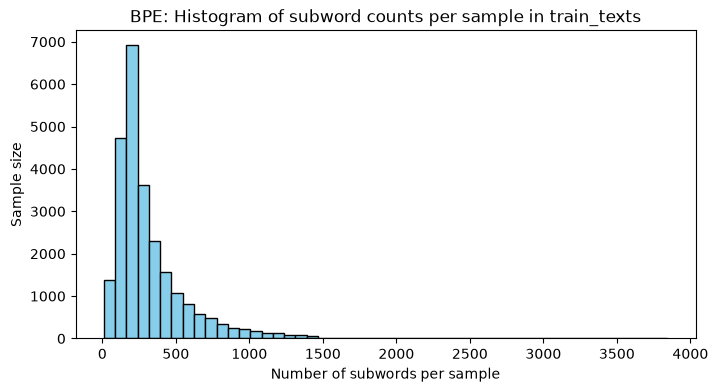

In [103]:
plt.figure(figsize=(8, 4))  # 创建 8×4 英寸的画布
plt.hist(sample_subword_counts, bins=50, color='skyblue', edgecolor='black')  # 直方图: 50 个区间
plt.xlabel('Number of subwords per sample')  # 横轴: 每条影评包含的 subword 个数
plt.ylabel('Sample size')  # 纵轴: 落在该区间的样本数量
plt.title('BPE: Histogram of subword counts per sample in train_texts')  # 图表标题
plt.show()  # 显示图像

In [104]:
# 观察直方图：绝大多数样本的子词数在几百以内，可据此把 max_length 设为 500（见下文）。
# 通常一条影评的子词数会略多于单词数（整词被拆分），但仍在同一量级。

## 10. Tokenizer 分词器类 —— 词级 / BPE 共用一个类
神经网络只能接收数字，不能直接接收文本。Tokenizer 负责:
  - encode: 文本列表 → 填充好的 ID 张量（会加 BOS/EOS，并 padding 到 batch 内等长）
  - decode: ID 序列 → 文本（便于验证编码是否正确）
关键设计 —— padding 位置的选择（padding_first 参数）:
  默认 padding 在句尾（padding_first=False）:
    池化模型对位置不敏感，句尾 padding 即可
  置前 padding（padding_first=True）:
    RNN/LSTM 是从左往右读序列的，如果 padding 在句尾，最后一步的隐藏状态会包含大量
    padding 信息；把 padding 放到句首，句尾恰好是真实文本，取最后一步 hidden 才有意义
词级与 BPE 的文本都已经按各自的分词结果用空格分隔好了，Tokenizer 无需区分二者，
只需按空白切分 + 查表即可，因此两种分词复用同一个类。

In [105]:
class Tokenizer:
    """
    IMDB 分词器：完成文本与 ID 序列之间的转换（词级 / BPE 子词通用）

    特殊符号约定:
      <PAD>=0: 填充符     <OOV>=1: 未登录词/未登录子词
      <BOS>=2: 句首符     <EOS>=3: 句尾符
    """

    def __init__(self, vocab, oov_token='<OOV>', bos_token='<BOS>', eos_token='<EOS>', pad_token='<PAD>'):
        """
        初始化 Tokenizer

        参数:
            vocab:       词典 dict {token: ID}
            oov_token:   未登录词占位符名称，默认 '<OOV>'
            bos_token:   句首符名称，默认 '<BOS>'
            eos_token:   句尾符名称，默认 '<EOS>'
            pad_token:   填充符名称，默认 '<PAD>'
        """
        self.vocab = vocab  # 保存词典
        self.id2word = {idx: word for word, idx in vocab.items()}  # 构建 ID→token 反向词典
        self.oov_id = vocab.get(oov_token, 1)  # 获取 OOV 的 ID（词典中固定为 1）
        self.bos_id = vocab.get(bos_token, 2)  # 获取 BOS 的 ID（固定为 2）
        self.eos_id = vocab.get(eos_token, 3)  # 获取 EOS 的 ID（固定为 3）
        self.pad_id = vocab.get(pad_token, 0)  # 获取 PAD 的 ID（固定为 0）

    def encode(self, texts, add_bos=False, add_eos=False, max_length=500, padding_first=False):
        """
        文本列表 → 填充后的 ID 序列列表

        参数:
            texts:          文本字符串列表（一个元素一条影评，空格分隔 token）
            add_bos:        是否在序列开头添加 <BOS>（默认 False）
            add_eos:        是否在序列末尾添加 <EOS>（默认 False）
            max_length:     单条序列最大长度，超过则从右侧截断
            padding_first:  True=PAD 放在句首（RNN/LSTM 用）；False=PAD 放在句尾（池化用）
        返回:
            padded: list of list of int，已按本 batch 最大长度填充（且不超过 max_length）
        """
        encoded = []  # 存放每个样本的 ID 序列
        seq_lengths = []  # 存放每个样本的原始长度（未 padding 前），用于计算 batch 最大长度
        for text in texts:  # 一个 text 就是一个样本
            ids = []  # 当前样本的 ID 序列
            if add_bos:  # 如果需要句首符
                ids.append(self.bos_id)  # 在序列最前面加入 <BOS>
            for word in text.split():  # 按空白切分出每个 token（单词或 subword）
                # vocab.get(word, self.oov_id): token 在词典中取对应 ID，否则取 <OOV> 的 ID
                ids.append(self.vocab.get(word, self.oov_id))  # 查词典得到该 token 的 ID
            if add_eos:  # 如果需要句尾符
                ids.append(self.eos_id)  # 在序列最后加入 <EOS>
            if len(ids) > max_length:  # 如果序列超过最大长度
                ids = ids[:max_length]  # 截断只保留前 max_length 个 token
            seq_lengths.append(len(ids))  # 记录该样本的序列长度
            encoded.append(ids)  # 把该样本的 ID 序列加入列表

        # 计算本 batch 的最大长度（不超过 max_length；encoded 为空则设为 0 防止除零）
        batch_max_len = min(max(seq_lengths), max_length) if encoded else 0

        # ---- PAD 填充：把所有样本补齐到 batch_max_len 等长 ----
        padded = []  # 存放填充后的等长序列
        for ids in encoded:  # 遍历每个样本的 ID 序列
            pad_length = batch_max_len - len(ids)  # 需要补的 PAD 数量
            if pad_length > 0:  # 该样本比 batch 最长样本短，需要填充
                if padding_first:  # 选择 PAD 前置
                    ids = [self.pad_id] * pad_length + ids  # PAD 加在前面，真实文本靠后
                else:  # 默认 PAD 后置
                    ids = ids + [self.pad_id] * pad_length  # PAD 加在后面，真实文本靠前
            padded.append(ids)  # 把填充后的序列加入结果列表
        return padded  # 返回形状为 (batch_size, batch_max_len) 的等长 ID 序列

    def decode(self, batch_ids, skip_special_tokens=False):
        """
        ID 序列 → 文本，用于验证编码是否正确

        参数:
            batch_ids:              list of list of int，一批 ID 序列
            skip_special_tokens:    True=跳过 <PAD>/<OOV>/<BOS>/<EOS> 等特殊符号
        返回:
            decoded: list of str，还原后的文本列表
        """
        decoded = []  # 存放还原后的文本
        special_ids = {self.oov_id, self.bos_id, self.eos_id, self.pad_id}  # 特殊符号 ID 集合
        for ids in batch_ids:  # 遍历每条 ID 序列
            words = []  # 当前序列还原出的 token 列表
            for idx in ids:  # 遍历序列中的每个 ID
                if skip_special_tokens and idx in special_ids:  # 跳过特殊符号
                    continue  # 不加入该 token
                words.append(self.id2word.get(idx, '<OOV>'))  # 反向查词典得到 token（查不到用 <OOV> 兜底）
            decoded.append(' '.join(words))  # 用空格连接 token，组成一句文本
        return decoded  # 返回还原出的文本列表

## 11. 实例化两个 Tokenizer 并测试

In [106]:
# 词级 tokenizer：基于 Counter 词频词典（vocab_word）
tokenizer_word = Tokenizer(vocab_word)  # 词级分词器

In [107]:
# BPE tokenizer：基于 BPE 子词词典（vocab_bpe）
tokenizer_bpe = Tokenizer(vocab_bpe)  # 子词分词器

### 词级 Tokenizer 测试：验证 encode / decode / 两种 padding

In [108]:
test_sentences_word = [  # 三个测试句子，其中含一个词典外的未知词
    "i am happy",  # 普通短句
    "this movie is so good",  # 稍长一点的句子
    "unknownword appear"  # 含未知词 unknownword（会映射为 <OOV>）
]
encoded_word = tokenizer_word.encode(test_sentences_word, add_bos=True, add_eos=True)  # 编码（句尾 padding）
print("\n词级 Tokenizer —— 编码后（padding 后置）:")
for i, sample in enumerate(encoded_word):  # 逐样本打印
    print(f"样本{i + 1}: {sample}")  # 可看到 <PAD>(0) 都补在序列末尾
encoded_word_first = tokenizer_word.encode(test_sentences_word, add_bos=True, add_eos=True, padding_first=True)  # 句首 padding
print("词级 Tokenizer —— 编码后（padding 前置）:")
for i, sample in enumerate(encoded_word_first):  # 逐样本打印
    print(f"样本{i + 1}: {sample}")  # 可看到 <PAD>(0) 都补在序列开头
decoded_word = tokenizer_word.decode(encoded_word, skip_special_tokens=True)  # 跳过特殊符号还原
print("词级 Tokenizer —— 解码跳过特殊符号后：")
for i, sample in enumerate(decoded_word):  # 逐样本打印
    print(f"样本{i + 1}: {sample}")  # 还原出原始句子


词级 Tokenizer —— 编码后（padding 后置）:
样本1: [2, 149, 251, 760, 3, 0, 0]
样本2: [2, 14, 21, 9, 43, 51, 3]
样本3: [2, 1, 965, 3, 0, 0, 0]
词级 Tokenizer —— 编码后（padding 前置）:
样本1: [0, 0, 2, 149, 251, 760, 3]
样本2: [2, 14, 21, 9, 43, 51, 3]
样本3: [0, 0, 0, 2, 1, 965, 3]
词级 Tokenizer —— 解码跳过特殊符号后：
样本1: i am happy
样本2: this movie is so good
样本3: appear


### BPE Tokenizer 测试：BPE 形式的长句能正确按 subword 查表

In [109]:
test_sentences_bpe = [  # 短句 + BPE 形式长句
    "i am happy",  # 普通短句
    "I rented I A@@ M C@@ U@@ RI@@ OU@@ S@@ -@@ Y@@ EL@@ LO@@ W from my video store "
    "because of all the controver@@ sy that surr@@ ounded it when it was first released "
    "in 196@@ 7. I also heard that at first it was se@@ i@@ zed by U.S. cust@@ om@@ s "
    "if it ever tried to enter this countr@@ y, therefore being a fan of films considered "  # 长句（BPE 形式）
]
encoded_bpe = tokenizer_bpe.encode(test_sentences_bpe, add_bos=True, add_eos=True)  # 编码（句尾 padding）
print("\nBPE Tokenizer —— 编码后（padding 后置）:")
for i, sample in enumerate(encoded_bpe):  # 逐样本打印
    print(f"样本{i + 1}: {sample}")  # BPE 形式的长句按 subword 查表得到一长串 ID
decoded_bpe = tokenizer_bpe.decode(encoded_bpe, skip_special_tokens=True)  # 跳过特殊符号还原
print("BPE Tokenizer —— 解码跳过特殊符号后：")
for i, sample in enumerate(decoded_bpe):  # 逐样本打印
    print(f"样本{i + 1}: {sample}")  # 还原出 subword 序列


BPE Tokenizer —— 编码后（padding 后置）:
样本1: [2, 99, 315, 1542, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
样本2: [2, 11, 3684, 11, 132, 1832, 94, 398, 2977, 1833, 62, 46, 345, 4302, 1735, 2793, 38, 79, 942, 3071, 119, 7, 40, 4, 8014, 1736, 12, 3142, 3402, 14, 69, 14, 16, 146, 1590, 10, 2341, 6857, 11, 142, 1122, 12, 32, 146, 14, 16, 263, 135, 1018, 33, 5979, 6404, 386, 60, 78, 14, 204, 1672, 8, 4744, 13, 2884, 127, 5560, 176, 5, 807, 7, 247, 2643, 3]
BPE Tokenizer —— 解码跳过特殊符号后：
样本1: i am happy
样本2: I rented I A@@ M C@@ U@@ RI@@ OU@@ S@@ -@@ Y@@ EL@@ LO@@ W from my video store because of all the controver@@ sy that surr@@ ounded it when it was first released in 196@@ 7. I also heard that at first it was se@@ i@@ zed by U.S. cust@@ om@@ s if it ever tried to enter this countr@@ y, therefore being a fan of films considered


## 12. 自定义 Dataset 类 与 create_collate_fn 组 batch 回调
与图像任务不同，文本长度不一，无法直接堆叠成一个张量。
所以我们先让 Dataset 返回原始 (text, label)，再由 DataLoader 的
collate_fn 统一调用 Tokenizer.encode 完成"文本 → 填充 ID 张量"的转换。

### 先看一个 Python 小技巧: zip(*lists) 按列拆分
collate_fn 里用 `texts, labels = zip(*batch)` 把一个 batch 的 (text, label)
对拆成两个元组，原理与下面这个 demo 完全一致：

In [110]:
list1 = [1, 2]  # 模拟第一个样本的 (特征, 标签)
list2 = [3, 4]  # 模拟第二个样本的 (特征, 标签)
list3 = [5, 6]  # 模拟第三个样本的 (特征, 标签)
list4 = [7, 8]  # 模拟第四个样本的 (特征, 标签)
list5 = [9, 10]  # 模拟第五个样本的 (特征, 标签)
lists = [list1, list2, list3, list4, list5]  # 一批样本 [(特征, 标签), ...]
i, out = zip(*lists)  # 解包: i 收集所有"特征"，out 收集所有"标签"
print(i)  # (1, 3, 5, 7, 9)
print(out)  # (2, 4, 6, 8, 10)

(1, 3, 5, 7, 9)
(2, 4, 6, 8, 10)


In [111]:
class IMDBDataset(Dataset):
    """
    IMDB 情感分类数据集

    每个样本返回 (原始文本字符串, 整数标签)，不对文本做任何处理。
    真正的 token 化与 padding 工作交给 collate_fn 在组 batch 时完成。
    """

    def __init__(self, texts, labels):
        """
        初始化数据集

        参数:
            texts:  文本数组/列表，每个元素为一条影评（词级或 BPE 分词结果）
            labels: 标签数组，0=负面，1=正面
        """
        self.texts = texts  # 保存文本
        self.labels = labels  # 保存标签数组

    def __len__(self):
        """返回数据集样本总数"""
        return len(self.texts)  # 样本数 = 文本条数

    def __getitem__(self, idx):
        """
        按索引获取单个样本

        参数:
            idx: 样本索引
        返回:
            (text, label): 文本字符串与整数标签
        """
        return self.texts[idx], int(self.labels[idx])  # 返回 (原文, 标签)，标签转成 Python int


def create_collate_fn(tokenizer, add_bos=False, add_eos=False, max_length=500, padding_first=False):
    """
    创建 DataLoader 的 collate_fn 回调函数

    组 batch 时把一批 (text, label) 整理成模型可直接消费的张量:
      input_ids: LongTensor (batch_size, seq_len)，已加 BOS/EOS 并 padding 到等长
      labels:    LongTensor (batch_size,)

    参数:
        tokenizer:      Tokenizer 实例，负责把文本编码为 ID 并 padding
        add_bos:        是否在序列开头加 <BOS>
        add_eos:        是否在序列末尾加 <EOS>
        max_length:     单条序列最大长度
        padding_first:  True=PAD 前置（RNN/LSTM 用），False=PAD 后置（池化用）
    返回:
        collate_fn: 可供 DataLoader 使用的回调函数
    """

    def collate_fn(batch):
        """
        将一个 batch 的样本整理为模型输入

        参数:
            batch: [(text, label), ...] 列表
        返回:
            input_ids: LongTensor, shape (batch_size, seq_len)
            labels:    LongTensor, shape (batch_size,)
        """
        texts, labels = zip(*batch)  # 把特征和标签拆开（zip(*batch) 按列拆分元组列表）
        texts = list(texts)  # zip 结果转成 list 便于使用
        # 通过 tokenizer 把文本 batch 编码为 ID 并做 padding（返回等长 list）
        input_ids = tokenizer.encode(
            texts,
            add_bos=add_bos,
            add_eos=add_eos,
            max_length=max_length,
            padding_first=padding_first,
        )
        input_ids = torch.tensor(input_ids, dtype=torch.long)  # list → LongTensor (batch, seq_len)
        labels = torch.tensor(labels, dtype=torch.long)  # list → LongTensor (batch,)
        return input_ids, labels  # 返回模型输入与标签

    return collate_fn  # 返回闭包作为 DataLoader 的 collate_fn

## 13. 为两种分词构建 Dataset 与 DataLoader
每种分词都创建 4 个 DataLoader：
  - 池化模型用: PAD 后置（对位置不敏感，句尾 padding 即可）
  - RNN/LSTM 用: PAD 前置（循环模型取最后一步 hidden，句尾 padding 会污染它）
因此两种分词 × 两类 loader = 4 组。

### 词级 Dataset 与 collate

In [112]:
train_dataset_word = IMDBDataset(train_texts_word, train_labels)  # 词级训练集 Dataset
test_dataset_word = IMDBDataset(test_texts_word, test_labels)  # 词级测试集 Dataset
collate_fn_word_pooling = create_collate_fn(tokenizer_word, add_bos=True, add_eos=True, max_length=500, padding_first=False)  # 词级池化: 句尾 padding
collate_fn_word_recurrent = create_collate_fn(tokenizer_word, add_bos=True, add_eos=True, max_length=500, padding_first=True)  # 词级循环: 句首 padding

### BPE Dataset 与 collate

In [113]:
train_dataset_bpe = IMDBDataset(train_texts_bpe, train_labels)  # BPE 训练集 Dataset
test_dataset_bpe = IMDBDataset(test_texts_bpe, test_labels)  # BPE 测试集 Dataset
collate_fn_bpe_pooling = create_collate_fn(tokenizer_bpe, add_bos=True, add_eos=True, max_length=500, padding_first=False)  # BPE 池化: 句尾 padding
collate_fn_bpe_recurrent = create_collate_fn(tokenizer_bpe, add_bos=True, add_eos=True, max_length=500, padding_first=True)  # BPE 循环: 句首 padding

### 词级 DataLoader

In [114]:
train_loader_word_pooling = DataLoader(
    train_dataset_word, batch_size=32, shuffle=True, collate_fn=collate_fn_word_pooling,  # 词级池化训练
)
test_loader_word_pooling = DataLoader(
    test_dataset_word, batch_size=32, shuffle=False, collate_fn=collate_fn_word_pooling,  # 词级池化测试
)
train_loader_word_recurrent = DataLoader(
    train_dataset_word, batch_size=32, shuffle=True, collate_fn=collate_fn_word_recurrent,  # 词级循环训练
)
test_loader_word_recurrent = DataLoader(
    test_dataset_word, batch_size=32, shuffle=False, collate_fn=collate_fn_word_recurrent,  # 词级循环测试
)

### BPE DataLoader

In [115]:
train_loader_bpe_pooling = DataLoader(
    train_dataset_bpe, batch_size=32, shuffle=True, collate_fn=collate_fn_bpe_pooling,  # BPE 池化训练
)
test_loader_bpe_pooling = DataLoader(
    test_dataset_bpe, batch_size=32, shuffle=False, collate_fn=collate_fn_bpe_pooling,  # BPE 池化测试
)
train_loader_bpe_recurrent = DataLoader(
    train_dataset_bpe, batch_size=32, shuffle=True, collate_fn=collate_fn_bpe_recurrent,  # BPE 循环训练
)
test_loader_bpe_recurrent = DataLoader(
    test_dataset_bpe, batch_size=32, shuffle=False, collate_fn=collate_fn_bpe_recurrent,  # BPE 循环测试
)

## 14. 批量验证 —— 取一个 batch 查看形状与内容
分别验证词级与 BPE 的循环模型 loader，确认形状正确、编码解码无误。

In [116]:
for loader_name, loader, tokenizer in [
    ("词级", train_loader_word_recurrent, tokenizer_word),
    ("BPE", train_loader_bpe_recurrent, tokenizer_bpe),
]:
    for batch_idx, (input_ids, labels) in enumerate(loader):  # 各取第一个 batch
        print(f"\n========== {loader_name} Batch {batch_idx} 验证 ==========")
        print(f"  input_ids shape: {input_ids.shape}")  # torch.Size([32, 500]) —— (batch, seq_len)
        print(f"  labels shape:    {labels.shape}")  # torch.Size([32]) —— (batch,)
        print(f"  首条 input_ids 前15个:  {input_ids[0][:15].tolist()}")  # PAD(0) 前置在句首
        print(f"  首条 label:      {labels[0].item()}")  # 打印第一个样本的标签
        # 解码验证文本转 ID 是否正确（跳过特殊符号还原出原文）
        decoded = tokenizer.decode([input_ids[0].tolist()], skip_special_tokens=True)  # 解码单条
        print(f"  解码还原:        {decoded[0][:80]}...")  # 打印还原出的文本前 80 字符
        break  # 只验证一个 batch 后跳出


========== 词级 Batch 0 验证 ==========
  input_ids shape: torch.Size([32, 500])
  labels shape:    torch.Size([32])
  首条 input_ids 前15个:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  首条 label:      0
  解码还原:        After watching this I had lost a little respect for Christopher Lee (This has pa...

========== BPE Batch 0 验证 ==========
  input_ids shape: torch.Size([32, 500])
  labels shape:    torch.Size([32])
  首条 input_ids 前15个:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  首条 label:      0
  解码还原:        It's a hide@@ ous little production, ap@@ t to give one nightma@@ res as well as...


## 15. Trainer 通用训练器类 —— 二分类专用
封装完整的二分类训练流水线：训练循环 + 验证评估 + 曲线绘图。
与图像分类（CrossEntropyLoss + argmax）不同，本任务使用:
  - BCEWithLogitsLoss 二分类损失（模型输出 1 维 logit，>0 判为类别 1）
  - 准确率: outputs.squeeze() > 0 与标签比较

In [117]:
class Trainer:
    """
    通用训练器（二分类）: 封装训练循环、评估、损失/准确率记录与可视化

    使用方式:
      trainer = Trainer(model, train_loader, val_loader, optimizer, criterion, device)
      trainer.fit(epochs)   # 训练 epochs 轮
      trainer.plot()        # 绘制损失与准确率曲线
    """

    def __init__(self, model, train_loader, val_loader, optimizer, criterion, device):
        """
        初始化训练器

        参数:
            model:        待训练的 PyTorch 模型（nn.Module）
            train_loader: 训练集 DataLoader
            val_loader:   验证集 DataLoader
            optimizer:    优化器（如 Adam）
            criterion:    损失函数（二分类用 BCEWithLogitsLoss）
            device:       训练设备 'cuda' 或 'cpu'
        """
        self.model = model  # 保存模型
        self.train_loader = train_loader  # 保存训练集加载器
        self.val_loader = val_loader  # 保存验证集加载器
        self.optimizer = optimizer  # 保存优化器
        self.criterion = criterion  # 保存损失函数
        self.device = device  # 保存设备

        # 训练历史记录（每个 epoch 记录一次，用于最终绘图）
        self.train_losses = []  # 每轮训练集平均损失
        self.val_losses = []  # 每轮验证集平均损失
        self.train_accs = []  # 每轮训练集准确率
        self.val_accs = []  # 每轮验证集准确率

    def train_one_epoch(self):
        """
        训练一个 epoch: 遍历全部训练 batch，前向 → 反向 → 更新参数

        返回:
            avg_loss: 本轮平均训练损失
            acc:      本轮训练集准确率（0~1 小数）
        """
        self.model.train()  # 切换到训练模式
        running_loss = 0.0  # 损失累加器（按样本数加权，最后除以总样本数）
        correct = 0  # 预测正确的样本数
        total = 0  # 总样本数

        for inputs, labels in self.train_loader:  # 遍历每个 batch
            inputs = inputs.to(self.device)  # 输入 ID 张量移至设备
            labels = labels.to(self.device)  # 标签移至设备
            self.optimizer.zero_grad()  # 1. 清空上一步累积的梯度
            outputs = self.model(inputs)  # 2. 前向传播，输出形状 (batch, 1) 的 logit
            # 输出层为 1 个神经元，去掉多余的维度 (batch,1)→(batch,)，方便算损失和准确率
            outputs = outputs.squeeze()  # squeeze 掉最后一维
            loss = self.criterion(outputs, labels.float())  # 3. 计算二分类损失（标签转 float）
            loss.backward()  # 4. 反向传播求梯度
            self.optimizer.step()  # 5. 更新参数
            running_loss += loss.item() * inputs.size(0)  # 累加损失（乘以样本数做加权，便于求平均）

            # ---- 二分类准确率计算 ----
            preds = outputs > 0  # logit > 0 预测为正类（得到布尔张量）
            correct += (preds == labels).sum().item()  # 预测与真实标签相等的个数
            total += labels.size(0)  # 累加本 batch 样本数

        avg_loss = running_loss / total  # 平均损失 = 加权总损失 / 总样本数
        acc = correct / total  # 准确率 = 正确数 / 总数（0~1）
        return avg_loss, acc  # 返回 (平均损失, 准确率)

    def evaluate(self):
        """
        在验证集上评估: 只做前向，不更新参数

        返回:
            avg_loss: 平均验证损失
            acc:      验证集准确率（0~1 小数）
        """
        self.model.eval()  # 切换到评估模式
        running_loss = 0.0  # 损失累加器
        correct = 0  # 预测正确的样本数
        total = 0  # 总样本数
        with torch.no_grad():  # 禁用梯度计算，节省显存并加速（评估不需要梯度）
            for inputs, labels in self.val_loader:  # 遍历验证集每个 batch
                inputs = inputs.to(self.device)  # 输入移至设备
                labels = labels.to(self.device)  # 标签移至设备
                outputs = self.model(inputs)  # 前向传播，得到 logit (batch,1)
                outputs = outputs.squeeze()  # 去掉最后一维 (batch,1)→(batch,)
                loss = self.criterion(outputs, labels.float())  # 计算二分类损失
                running_loss += loss.item() * inputs.size(0)  # 加权累加损失
                preds = outputs > 0  # logit > 0 判为正类
                correct += (preds == labels).sum().item()  # 累计正确数
                total += labels.size(0)  # 累计样本数

        avg_loss = running_loss / total  # 平均验证损失
        acc = correct / total  # 验证准确率
        return avg_loss, acc  # 返回 (平均损失, 准确率)

    def fit(self, epochs):
        """
        训练主循环: 逐轮调用 train_one_epoch + evaluate，记录历史

        参数:
            epochs: 训练轮数
        """
        for epoch in range(epochs):  # 逐轮训练
            train_loss, train_acc = self.train_one_epoch()  # 训练一个 epoch
            val_loss, val_acc = self.evaluate()  # 在验证集上评估
            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            self.train_accs.append(train_acc)  # 记录训练准确率
            self.val_accs.append(val_acc)  # 记录验证准确率

            # 打印当前 epoch 的损失与准确率
            print(f'Epoch {epoch + 1}/{epochs}: '  # 当前轮数
                  f'Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | '  # 训练指标
                  f'Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f}')  # 验证指标

    def plot(self):
        """
        绘制训练/验证的损失曲线与准确率曲线（两张子图并排）
        """
        epochs = range(1, len(self.train_losses) + 1)  # 横轴: epoch 编号（从 1 开始）
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 创建 1 行 2 列的子图，12×5 英寸

        # ---- 左子图: 损失曲线 ----
        axs[0].plot(epochs, self.train_losses, label='Train Loss')  # 训练损失折线
        axs[0].plot(epochs, self.val_losses, label='Validation Loss')  # 验证损失折线
        axs[0].set_title('Loss')  # 子图标题
        axs[0].set_xlabel('Epoch')  # 横轴标签
        axs[0].set_ylabel('Loss')  # 纵轴标签
        axs[0].legend()  # 显示图例
        axs[0].grid(True)  # 显示网格

        # ---- 右子图: 准确率曲线 ----
        axs[1].plot(epochs, self.train_accs, label='Train Accuracy')  # 训练准确率折线
        axs[1].plot(epochs, self.val_accs, label='Validation Accuracy')  # 验证准确率折线
        axs[1].set_title('Accuracy')  # 子图标题
        axs[1].set_xlabel('Epoch')  # 横轴标签
        axs[1].set_ylabel('Accuracy')  # 纵轴标签
        axs[1].legend()  # 显示图例
        axs[1].grid(True)  # 显示网格

        plt.tight_layout()  # 自动调整子图间距，避免重叠
        plt.show()  # 显示图像

## 16. nn.LSTM 层基础 —— 单层单向 / 双向 / 双层 对比
循环网络的核心是"按时间步从左到右读取序列"，每个时间步的隐藏状态
h_t 整合了到当前位置为止的全部上下文。nn.LSTM 相比 nn.RNN 增加了
细胞状态 c_t（长期记忆），能更好地缓解梯度消失问题。
三个正交的超参数：
  input_size:   每个时间步输入的维度（本任务中为 Embedding 维度）
  hidden_size:  隐藏状态 h_t 的维度
  num_layers:   纵向堆叠的层数（上层接收下层的输出）
  bidirectional:是否横向双向读取（正向一遍 + 反向一遍）
注意 nn.LSTM 的权重命名规则: weight_ih_l0 表示"第0层 输入→隐藏"权重，
维度为 (hidden*4, input)。乘 4 是因为 LSTM 内部有 4 个门（输入门 i、
遗忘门 f、输出门 o、候选记忆 g），每个门都有自己的权重。

### 16.1 单层单向 LSTM
参数形状: weight_ih_l0 (80, 10) —— 4 门 × hidden20 = 80 行，input10 列

In [118]:
lstm = nn.LSTM(input_size=10, hidden_size=20, num_layers=1, batch_first=True)  # 单层单向 LSTM

In [119]:
print("\nLSTM weights and biases:")  # 打印该 LSTM 层的参数
for name, param in lstm.named_parameters():  # 遍历命名参数
    print(f"  {name}: shape={param.shape}")  # weight_ih_l0 / weight_hh_l0 / bias_ih_l0 / bias_hh_l0

# 随机输入: 假设 batch_size=4, seq_len=7, input_size=10
x = torch.randn(4, 7, 10)  # (batch_size, seq_len, input_size)


LSTM weights and biases:
  weight_ih_l0: shape=torch.Size([80, 10])
  weight_hh_l0: shape=torch.Size([80, 20])
  bias_ih_l0: shape=torch.Size([80])
  bias_hh_l0: shape=torch.Size([80])


In [120]:
# 前向传播: 返回 (output, (hn, cn))
output, (hn, cn) = lstm(x)  # 解包输出

In [121]:
print("output shape:", output.shape)  # (batch_size, seq_len, hidden_size=20)：每个时间步的输出
print("hn shape:", hn.shape)  # (num_layers, batch_size, hidden_size)：最后一个时间步的隐藏状态
print("cn shape:", cn.shape)  # (num_layers, batch_size, hidden_size)：最后一个时间步的细胞状态

output shape: torch.Size([4, 7, 20])
hn shape: torch.Size([1, 4, 20])
cn shape: torch.Size([1, 4, 20])


### 16.2 双向 LSTM（bidirectional=True）
双向: 同时正向读一遍 + 反向读一遍，两个方向的隐藏状态在输出维度上拼接。
关键影响: output 最后一维 = hidden*2；hn/cn 第一维 = num_layers*2。
反向权重以 _reverse 后缀命名（如 weight_ih_l0_reverse）。

In [122]:
lstm = nn.LSTM(
    input_size=10,  # 每个时间步输入维度
    hidden_size=20,  # 单方向的隐藏维度
    num_layers=1,  # 层数
    batch_first=True,  # 输入 (batch, seq, input)
    bidirectional=True,  # 开启双向
)

In [123]:
print("\nBidirectional LSTM weights and biases:")  # 打印双向 LSTM 的参数
for name, param in lstm.named_parameters():  # 遍历命名参数
    print(f"  {name}: shape={param.shape}")  # 多出 4 个 _reverse 反向权重

x = torch.randn(4, 7, 10)  # 随机输入 (batch, seq, input)


Bidirectional LSTM weights and biases:
  weight_ih_l0: shape=torch.Size([80, 10])
  weight_hh_l0: shape=torch.Size([80, 20])
  bias_ih_l0: shape=torch.Size([80])
  bias_hh_l0: shape=torch.Size([80])
  weight_ih_l0_reverse: shape=torch.Size([80, 10])
  weight_hh_l0_reverse: shape=torch.Size([80, 20])
  bias_ih_l0_reverse: shape=torch.Size([80])
  bias_hh_l0_reverse: shape=torch.Size([80])


In [124]:
output, (hn, cn) = lstm(x)  # 前向传播

In [125]:
print("output shape:", output.shape)  # (batch, seq, hidden*2=40)
print("hn shape:", hn.shape)  # (num_layers*2=2, batch, hidden=20)
print("cn shape:", cn.shape)  # (num_layers*2=2, batch, hidden=20)

output shape: torch.Size([4, 7, 40])
hn shape: torch.Size([2, 4, 20])
cn shape: torch.Size([2, 4, 20])


### 16.3 双层单向 LSTM（num_layers=2）
双层: 第 0 层读原始输入，第 1 层把第 0 层的输出当输入。
因此 weight_ih_l1 的输入维度从 input_size 变成 hidden_size。

In [126]:
lstm = nn.LSTM(
    input_size=10,  # 每个时间步输入维度
    hidden_size=20,  # 隐藏维度
    num_layers=2,  # 两层
    batch_first=True,  # 输入 (batch, seq, input)
    bidirectional=False,  # 单向
)

In [127]:
print("\n2-layer unidirectional LSTM weights and biases:")  # 打印双层 LSTM 的参数
for name, param in lstm.named_parameters():  # 遍历命名参数
    print(f"  {name}: shape={param.shape}")  # l1 层的 input 维度是 20（上一层 hidden）

x = torch.randn(4, 7, 10)  # 随机输入 (batch, seq, input)


2-layer unidirectional LSTM weights and biases:
  weight_ih_l0: shape=torch.Size([80, 10])
  weight_hh_l0: shape=torch.Size([80, 20])
  bias_ih_l0: shape=torch.Size([80])
  bias_hh_l0: shape=torch.Size([80])
  weight_ih_l1: shape=torch.Size([80, 20])
  weight_hh_l1: shape=torch.Size([80, 20])
  bias_ih_l1: shape=torch.Size([80])
  bias_hh_l1: shape=torch.Size([80])


In [128]:
output, (hn, cn) = lstm(x)  # 前向传播

In [129]:
print("output shape:", output.shape)  # (batch, seq, hidden=20)
print("hn shape:", hn.shape)  # (num_layers=2, batch, hidden=20)
print("cn shape:", cn.shape)  # (num_layers=2, batch, hidden=20)

output shape: torch.Size([4, 7, 20])
hn shape: torch.Size([2, 4, 20])
cn shape: torch.Size([2, 4, 20])


## 17. 模型一：Embedding + 平均池化 + 全连接 分类器
数据流: (bs, seq_len) → Embedding → (bs, seq_len, embed_dim)
        → 平均池化 → (bs, embed_dim) → 全连接 → (bs, 1)
思路: 把一句话的所有 token 的 Embedding 求平均，得到整句话的"平均语义向量"，
      再通过全连接层映射为 1 维 logit。完全不关心 token 的先后顺序，
      等价于"词袋/子词袋（Bag of Words/Subwords）"式的文本表示。

In [130]:
class PoolingSentimentClassifier(nn.Module):
    """
    Embedding + 平均池化 情感分类器（不建模 token 顺序）

    结构概览:
      Embedding(vocab, 128) → AdaptiveAvgPool1d(1) → Linear(128→1)
    参数量主要由 Embedding 表决定: 词级 20000×128≈2.56M，BPE 8298×128≈1.06M
    """

    def __init__(self, vocab_size, embed_dim=128, num_class=1, padding_idx=0):
        """
        初始化模型

        参数:
            vocab_size:  词典大小（Embedding 表的行数）
            embed_dim:   Embedding 向量维度，默认 128
            num_class:   输出类别数，二分类为 1
            padding_idx: PAD 的 ID，默认 0。指定后 <PAD> 位置的 Embedding 恒为 0，不参与学习
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        # Embedding 层: 把每个 token 的 ID 查表得到 128 维向量
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        # 自适应平均池化层: 输出长度固定为 1，把整句的 Embedding 序列压缩成一个向量
        self.pool = nn.AdaptiveAvgPool1d(1)  # 1 代表池化后最后一个维度长度为 1
        # 全连接分类层: 128 维平均向量 → 1 维 logit（配合 BCEWithLogitsLoss）
        self.fc = nn.Linear(embed_dim, num_class)  # (bs, 128) → (bs, 1)

    def forward(self, input_ids):
        """
        前向传播

        参数:
            input_ids: (batch_size, seq_len) 的 token ID 张量
        返回:
            out: (batch_size, 1) 的 logit 张量
        """
        # (bs, seq_len) → (bs, seq_len, embed_dim): 每个 token ID 查表得到向量
        x = self.embedding(input_ids)
        # AdaptiveAvgPool1d 的输入要求是 (batch, channels, length)，
        # 所以把 embed_dim 当成通道维度交换到第 2 维: (bs, embed_dim, seq_len)
        x = x.permute(0, 2, 1)
        # 平均池化: (bs, embed_dim, seq_len) → (bs, embed_dim, 1)，对所有 token 向量取平均
        x = self.pool(x)
        # 去掉长度为 1 的维度: (bs, embed_dim, 1) → (bs, embed_dim)
        x = x.squeeze(-1)
        # 全连接: (bs, embed_dim) → (bs, 1)，输出 logit（可直接用于 BCEWithLogitsLoss）
        out = self.fc(x)
        return out  # 返回 logits

## 18. 模型二：Embedding + RNN + 全连接 分类器
数据流: (bs, seq_len) → Embedding → (bs, seq_len, embed_dim)
        → RNN → (bs, hidden)（取最后一步隐藏状态）→ 全连接 → (bs, 1)
思路: RNN 按时间步从左到右"阅读"整句话，每个时间步的隐藏状态 h_t
      整合了到当前为止的全部上下文；句子读完时最后一步的隐藏状态
      就浓缩了整句话的信息，取它做分类。
为什么必须 PAD 前置: RNN 最后一步的隐藏状态取决于序列末尾的内容，
  如果 PAD 在句尾，最后一步读到的是 PAD，信息被污染；
  把 PAD 放到句首后，句尾恰好是真实文本，取最后一步才有意义。
扩展能力: 支持多层（num_layers>1）与双向（bidirectional=True）。
  - 双向 RNN 同时正向读一遍、反向读一遍，最后把两个方向的隐藏状态拼接。
  - 本脚本实际训练采用默认的单层单向配置。
先理清两个概念：层数（纵向堆叠）与方向（横向读序）是两个正交维度——
  单层 rnn_layers=1:  x_t → [RNN层] → h_t
  多层 rnn_layers=2:  x_t → [RNN层1] → h_t⁽¹⁾ → [RNN层2] → h_t⁽²⁾（层1的输出作为层2的输入）
  单向 bidirectional=False: 只从左往右读一遍，每个位置只含"过去+现在"的上下文
  双向 bidirectional=True:  同时正向读一遍、反向读一遍，两个方向隐藏状态拼接
    正向: i → love → rnn    反向: rnn ← love ← i
    每个位置同时有"过去 + 未来"的上下文（对 "not good" 这类要靠后词判断的否定句尤其重要）
    关键影响: 输出维度翻倍 → fc 输入维度 = hidden × 2（见 self.fc），参数量也约翻倍

In [131]:
class RNNSentimentClassifier(nn.Module):
    """
    Embedding + RNN 情感分类器（建模 token 顺序）

    结构概览:
      Embedding(vocab, 128) → RNN(128→256) → Linear(256→1)
    参数量主要由 Embedding 表决定: 词级≈2.66M，BPE≈1.16M
    """

    def __init__(
            self,
            vocab_size,  # 词典大小
            embed_dim=128,  # Embedding 向量维度
            num_class=1,  # 输出类别数（二分类为 1）
            padding_idx=0,  # PAD 的 ID
            rnn_hidden=256,  # RNN 隐藏状态维度
            rnn_layers=1,  # RNN 层数
            bidirectional=False  # 是否双向
    ):
        """
        初始化模型

        参数:
            vocab_size:   词典大小（Embedding 表的行数）
            embed_dim:    Embedding 向量维度
            num_class:    输出类别数
            padding_idx:  PAD 的 ID（其 Embedding 恒为 0）
            rnn_hidden:   RNN 隐藏状态维度，默认 256
            rnn_layers:   RNN 层数，默认 1
            bidirectional: 是否双向 RNN，默认 False
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)  # token 向量层
        self.rnn = nn.RNN(  # 标准 RNN 层（vanilla RNN: h_t = tanh(W_ih·x_t + W_hh·h_{t-1} + b)）
            input_size=embed_dim,  # 每个时间步输入是 embed_dim 维的 token 向量
            hidden_size=rnn_hidden,  # 隐藏状态维度
            num_layers=rnn_layers,  # RNN 层数
            batch_first=True,  # 输入形状为 (batch, seq_len, input_size) 而非 (seq_len, batch, ...)
            bidirectional=bidirectional  # 是否双向
        )
        self.bidirectional = bidirectional  # 保存是否双向
        self.num_directions = 2 if bidirectional else 1  # 双向 RNN 输出维度是单向的两倍
        self.rnn_hidden = rnn_hidden  # 保存隐藏维度（供 forward 使用）
        self.rnn_layers = rnn_layers  # 保存层数
        # 全连接层: 输入维度 = hidden × 方向数（双向时拼接两个方向 → hidden*2）
        self.fc = nn.Linear(rnn_hidden * self.num_directions, num_class)

    def forward(self, input_ids):
        """
        前向传播: 读取整句 → 取最后一步隐藏状态 → 全连接分类

        参数:
            input_ids: (batch_size, seq_len) 的 token ID 张量
        返回:
            out: (batch_size, 1) 的 logit 张量
        """
        # (bs, seq_len) → (bs, seq_len, embed_dim): 查表得到每个 token 的向量
        x = self.embedding(input_ids)
        # RNN 前向: 输入 (bs, seq_len, embed_dim)
        #   output: (bs, seq_len, hidden*dirs)  每个时间步的输出
        #   hn:     (num_layers*dirs, bs, hidden) 每层最后一个时间步的隐藏状态
        output, hn = self.rnn(x)
        # 取最后一层的隐藏状态作为整句的语义向量
        if self.bidirectional:  # 双向 RNN
            # hn[-2] 是正向最后一层最后一步，hn[-1] 是反向最后一层最后一步
            # 把两个方向的向量拼接: (bs, hidden*2)
            last_hidden = torch.cat([hn[-2], hn[-1]], dim=1)
        else:  # 单向 RNN
            last_hidden = hn[-1]  # (bs, hidden): 最后一层最后一步的隐藏状态
        # 全连接: (bs, hidden*dirs) → (bs, 1) logit
        out = self.fc(last_hidden)
        return out  # 返回 logits

## 19. 模型三：Embedding + LSTM + 全连接 分类器
数据流: (bs, seq_len) → Embedding → (bs, seq_len, embed_dim)
        → LSTM → (bs, hidden)（取最后一步隐藏状态）→ 全连接 → (bs, 1)
思路: LSTM 按时间步从左到右"阅读"整句话，每个时间步的隐藏状态 h_t
      整合了到当前为止的全部上下文；句子读完时最后一步的隐藏状态
      就浓缩了整句话的信息，取它做分类。
与 vanilla RNN 的区别: LSTM 内部多出一个"细胞状态" c_t（长期记忆），
  通过输入门 / 遗忘门 / 输出门 三个门控，选择性地记住或遗忘信息，
  能更好地缓解长序列上的梯度消失问题。
为什么必须 PAD 前置: LSTM 最后一步的隐藏状态取决于序列末尾的内容，
  如果 PAD 在句尾，最后一步读到的是 PAD，信息被污染；
  把 PAD 放到句首后，句尾恰好是真实文本，取最后一步才有意义。
扩展能力: 支持多层（num_layers>1）与双向（bidirectional=True）。
  本脚本实际训练采用默认的单层单向配置。
提示: nn.RNN / nn.LSTM / nn.GRU 三者的接口（构造参数与返回结构）完全一致；
  唯一的区别是 LSTM 前向返回 (output, (hn, cn))，比 RNN 多一个细胞状态 cn。

In [132]:
class LSTMSentimentClassifier(nn.Module):
    """
    Embedding + LSTM 情感分类器（建模 token 顺序）

    结构概览:
      Embedding(vocab, 128) → LSTM(128→256) → Linear(256→1)
    参数量主要由 Embedding 表决定: 词级≈2.96M，BPE≈1.46M
    """

    def __init__(
            self,
            vocab_size,  # 词典大小
            embed_dim=128,  # Embedding 向量维度
            num_class=1,  # 输出类别数（二分类为 1）
            padding_idx=0,  # PAD 的 ID
            lstm_hidden=256,  # LSTM 隐藏状态维度
            lstm_layers=1,  # LSTM 层数
            bidirectional=False  # 是否双向
    ):
        """
        初始化模型

        参数:
            vocab_size:    词典大小（Embedding 表的行数）
            embed_dim:     Embedding 向量维度
            num_class:     输出类别数
            padding_idx:   PAD 的 ID（其 Embedding 恒为 0）
            lstm_hidden:   LSTM 隐藏状态维度，默认 256
            lstm_layers:   LSTM 层数，默认 1
            bidirectional: 是否双向 LSTM，默认 False
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)  # token 向量层
        self.lstm = nn.LSTM(  # LSTM 层（含细胞状态 c_t，缓解梯度消失）
            input_size=embed_dim,  # 每个时间步输入是 embed_dim 维的 token 向量
            hidden_size=lstm_hidden,  # 隐藏状态维度
            num_layers=lstm_layers,  # LSTM 层数
            batch_first=True,  # 输入形状为 (batch, seq_len, input_size) 而非 (seq_len, batch, ...)
            bidirectional=bidirectional  # 是否双向
        )
        self.bidirectional = bidirectional  # 保存是否双向
        self.num_directions = 2 if bidirectional else 1  # 双向 LSTM 输出维度是单向的两倍
        self.lstm_hidden = lstm_hidden  # 保存隐藏维度
        self.lstm_layers = lstm_layers  # 保存层数
        # 全连接层: 输入维度 = hidden × 方向数（双向时拼接两个方向 → hidden*2）
        self.fc = nn.Linear(lstm_hidden * self.num_directions, num_class)

    def forward(self, input_ids):
        """
        前向传播: 读取整句 → 取最后一步隐藏状态 → 全连接分类

        参数:
            input_ids: (batch_size, seq_len) 的 token ID 张量
        返回:
            out: (batch_size, 1) 的 logit 张量
        """
        # (bs, seq_len) → (bs, seq_len, embed_dim): 查表得到每个 token 的向量
        x = self.embedding(input_ids)
        # LSTM 前向: 输入 (bs, seq_len, embed_dim)
        #   output: (bs, seq_len, hidden*dirs)     每个时间步的输出
        #   hn:     (num_layers*dirs, bs, hidden)  每层最后一个时间步的隐藏状态
        #   cn:     (num_layers*dirs, bs, hidden)  每层最后一个时间步的细胞状态
        output, (hn, cn) = self.lstm(x)
        # 取最后一层的隐藏状态作为整句的语义向量
        if self.bidirectional:  # 双向 LSTM
            # hn[-2] 是正向最后一层最后一步，hn[-1] 是反向最后一层最后一步
            # 把两个方向的向量拼接: (bs, hidden*2)
            last_hidden = torch.cat([hn[-2], hn[-1]], dim=1)
        else:  # 单向 LSTM
            last_hidden = hn[-1]  # (bs, hidden): 最后一层最后一步的隐藏状态
        # 全连接: (bs, hidden*dirs) → (bs, 1) logit
        out = self.fc(last_hidden)
        return out  # 返回 logits

## 20. 词级三模型 —— 实例化、前向验证与参数量统计

In [133]:
vocab_size_word = len(tokenizer_word.vocab)  # 词级词典大小 = 20000（Embedding 表行数）
vocab_size_bpe = len(tokenizer_bpe.vocab)  # BPE 词典大小 ≈ 8298（Embedding 表行数）
padding_idx = 0  # PAD 的 ID 为 0

### 词级三模型实例化（单层单向，与训练配置一致）

In [134]:
pooling_model_word = PoolingSentimentClassifier(vocab_size=vocab_size_word, embed_dim=128, padding_idx=padding_idx)  # 词级池化模型
rnn_model_word = RNNSentimentClassifier(
    vocab_size=vocab_size_word, embed_dim=128, padding_idx=padding_idx, rnn_layers=1, bidirectional=False  # 词级 RNN
)
lstm_model_word = LSTMSentimentClassifier(
    vocab_size=vocab_size_word, embed_dim=128, padding_idx=padding_idx, lstm_layers=1, bidirectional=False  # 词级 LSTM
)

In [135]:
# 打印词级模型结构（以 LSTM 为例，池化/RNN 结构见第 17/18 节）
print("\n========== 词级 Embedding + LSTM 结构 ==========")
print(lstm_model_word)  # Embedding(20000, 128) —— 词表大，Embedding 表大


========== 词级 Embedding + LSTM 结构 ==========
LSTMSentimentClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


### 词级前向传播验证：三个模型均能接收随机 ID 并输出 (batch, 1)

In [136]:
batch_size = 4  # 模拟 4 条影评
seq_len = 10  # 模拟每条影评 10 个 token
dummy_input_word = torch.randint(0, vocab_size_word, (batch_size, seq_len))  # 词级词表范围内的随机 ID
print("\n========== 词级前向传播验证 ==========")
print(f"dummy_input.shape: {dummy_input_word.shape}")  # torch.Size([4, 10])
print(f"词级池化输出 shape: {pooling_model_word(dummy_input_word).shape}")  # torch.Size([4, 1])
print(f"词级 RNN  输出 shape: {rnn_model_word(dummy_input_word).shape}")  # torch.Size([4, 1])
print(f"词级 LSTM 输出 shape: {lstm_model_word(dummy_input_word).shape}")  # torch.Size([4, 1])


========== 词级前向传播验证 ==========
dummy_input.shape: torch.Size([4, 10])
词级池化输出 shape: torch.Size([4, 1])
词级 RNN  输出 shape: torch.Size([4, 1])
词级 LSTM 输出 shape: torch.Size([4, 1])


### 词级参数量统计

In [137]:
def count_parameters(model):
    """统计模型的可训练参数量（requires_grad=True 的参数总数）"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)  # 累加每个参数的元素个数


print("\n========== 词级参数量统计 ==========")
total_params_word_pooling = count_parameters(pooling_model_word)  # 词级池化
total_params_word_rnn = count_parameters(rnn_model_word)  # 词级 RNN
total_params_word_lstm = count_parameters(lstm_model_word)  # 词级 LSTM
print(f"词级池化可训练参数总数: {total_params_word_pooling:,}")  # 约 2,560,129
print(f"词级 RNN  可训练参数总数: {total_params_word_rnn:,}")  # 约 2,659,073
print(f"词级 LSTM 可训练参数总数: {total_params_word_lstm:,}")  # 约 2,955,521


========== 词级参数量统计 ==========
词级池化可训练参数总数: 2,560,129
词级 RNN  可训练参数总数: 2,659,073
词级 LSTM 可训练参数总数: 2,955,521


In [138]:
# 打印词级 LSTM 各层参数 shape，对照第 16 节的权重命名规则理解
print("\n词级 LSTM 各层参数 shape:")
for name, param in lstm_model_word.named_parameters():  # 遍历所有命名参数
    print(f"Layer: {name}, Shape: {param.shape}")


词级 LSTM 各层参数 shape:
Layer: embedding.weight, Shape: torch.Size([20000, 128])
Layer: lstm.weight_ih_l0, Shape: torch.Size([1024, 128])
Layer: lstm.weight_hh_l0, Shape: torch.Size([1024, 256])
Layer: lstm.bias_ih_l0, Shape: torch.Size([1024])
Layer: lstm.bias_hh_l0, Shape: torch.Size([1024])
Layer: fc.weight, Shape: torch.Size([1, 256])
Layer: fc.bias, Shape: torch.Size([1])


## 21. 通用训练辅助函数 train_single_model
6 个模型的训练流程完全一样（设备 → 优化器 → Trainer → fit → plot → 评估），
抽成公共函数避免重复。对每个模型传入其模型对象与对应的 train/test loader。

In [139]:
def train_single_model(model, train_loader, val_loader, name, epochs=10):
    """
    训练单个模型并返回最终验证指标

    参数:
        model:        待训练模型（nn.Module）
        train_loader: 该模型的训练 DataLoader
        val_loader:   该模型的验证 DataLoader（使用测试集）
        name:         模型名称（用于打印）
        epochs:       训练轮数，默认 10
    返回:
        (val_loss, val_acc): 最终验证损失与准确率
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 优先 GPU
    model = model.to(device)  # 模型移至设备
    criterion = nn.BCEWithLogitsLoss()  # 二分类损失
    optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Adam 优化器，学习率 1e-3

    # 创建训练器并训练
    trainer = Trainer(model, train_loader, val_loader, optimizer, criterion, device)
    print(f"\n========== 开始训练 {name} (epochs={epochs}) ==========")
    trainer.fit(epochs)  # 训练 epochs 轮
    trainer.plot()  # 绘制损失与准确率曲线

    # 最终评估
    val_loss, val_acc = trainer.evaluate()
    print(f"\n{name} - Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")  # 打印最终结果
    return val_loss, val_acc  # 返回最终验证指标

## 22. 训练词级三个模型并绘制训练曲线
词级（分词方式一）数据来自 train_texts_word / test_texts_word，
池化模型用 PAD 后置 loader，RNN/LSTM 用 PAD 前置 loader。
参考效果：10 轮后 Train Acc≈0.95，Val Acc≈0.85 左右；脚本未固定随机种子，每次运行略有波动。


========== 开始训练 词级 Embedding+平均池化 (epochs=10) ==========
Epoch 1/10: Train Loss=0.6307 | Train Acc=0.7130 | Val Loss=0.5341 | Val Acc=0.7958
Epoch 2/10: Train Loss=0.4314 | Train Acc=0.8480 | Val Loss=0.3903 | Val Acc=0.8562
Epoch 3/10: Train Loss=0.3221 | Train Acc=0.8876 | Val Loss=0.3333 | Val Acc=0.8734
Epoch 4/10: Train Loss=0.2676 | Train Acc=0.9054 | Val Loss=0.3128 | Val Acc=0.8792
Epoch 5/10: Train Loss=0.2318 | Train Acc=0.9186 | Val Loss=0.2941 | Val Acc=0.8855
Epoch 6/10: Train Loss=0.2037 | Train Acc=0.9301 | Val Loss=0.2871 | Val Acc=0.8868
Epoch 7/10: Train Loss=0.1812 | Train Acc=0.9386 | Val Loss=0.2827 | Val Acc=0.8885
Epoch 8/10: Train Loss=0.1625 | Train Acc=0.9475 | Val Loss=0.2853 | Val Acc=0.8873
Epoch 9/10: Train Loss=0.1457 | Train Acc=0.9536 | Val Loss=0.2861 | Val Acc=0.8874
Epoch 10/10: Train Loss=0.1308 | Train Acc=0.9592 | Val Loss=0.2908 | Val Acc=0.8867


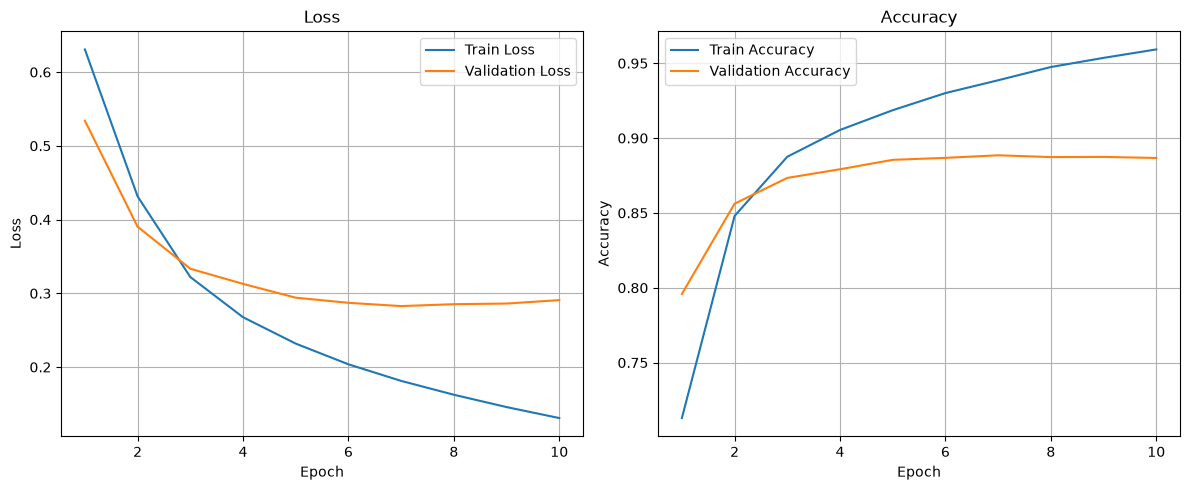


词级 Embedding+平均池化 - Val Loss: 0.2908, Val Accuracy: 0.8867


In [140]:
word_pooling_loss, word_pooling_acc = train_single_model(
    pooling_model_word, train_loader_word_pooling, test_loader_word_pooling, "词级 Embedding+平均池化"
)  # 词级池化模型


========== 开始训练 词级 Embedding+RNN (epochs=10) ==========
Epoch 1/10: Train Loss=0.6862 | Train Acc=0.5530 | Val Loss=0.6748 | Val Acc=0.5778
Epoch 2/10: Train Loss=0.6694 | Train Acc=0.5796 | Val Loss=0.6814 | Val Acc=0.5795
Epoch 3/10: Train Loss=0.6305 | Train Acc=0.6303 | Val Loss=0.7112 | Val Acc=0.5674
Epoch 4/10: Train Loss=0.5948 | Train Acc=0.6752 | Val Loss=0.5586 | Val Acc=0.7080
Epoch 5/10: Train Loss=0.5389 | Train Acc=0.7281 | Val Loss=0.6681 | Val Acc=0.5664
Epoch 6/10: Train Loss=0.5784 | Train Acc=0.6852 | Val Loss=0.6123 | Val Acc=0.6753
Epoch 7/10: Train Loss=0.5065 | Train Acc=0.7497 | Val Loss=0.6993 | Val Acc=0.5271
Epoch 8/10: Train Loss=0.5836 | Train Acc=0.6770 | Val Loss=0.6661 | Val Acc=0.5833
Epoch 9/10: Train Loss=0.5321 | Train Acc=0.7242 | Val Loss=0.6114 | Val Acc=0.6856
Epoch 10/10: Train Loss=0.4612 | Train Acc=0.7814 | Val Loss=0.6092 | Val Acc=0.7145


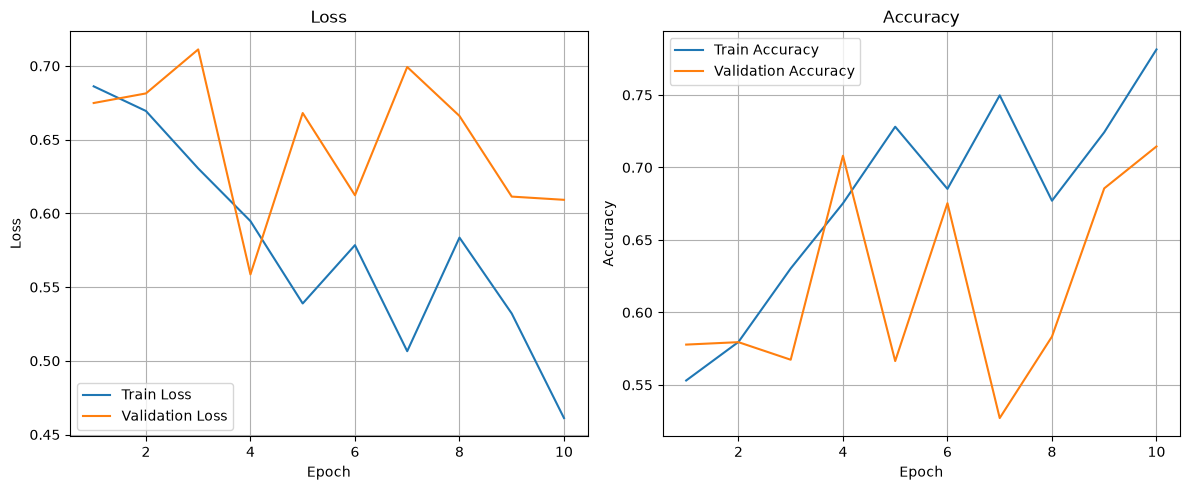


词级 Embedding+RNN - Val Loss: 0.6092, Val Accuracy: 0.7145


In [141]:
word_rnn_loss, word_rnn_acc = train_single_model(
    rnn_model_word, train_loader_word_recurrent, test_loader_word_recurrent, "词级 Embedding+RNN"
)  # 词级 RNN 模型


========== 开始训练 词级 Embedding+LSTM (epochs=10) ==========
Epoch 1/10: Train Loss=0.6445 | Train Acc=0.6218 | Val Loss=0.6024 | Val Acc=0.6695
Epoch 2/10: Train Loss=0.4410 | Train Acc=0.7986 | Val Loss=0.3689 | Val Acc=0.8412
Epoch 3/10: Train Loss=0.2597 | Train Acc=0.8953 | Val Loss=0.3307 | Val Acc=0.8659
Epoch 4/10: Train Loss=0.1729 | Train Acc=0.9353 | Val Loss=0.2913 | Val Acc=0.8808
Epoch 5/10: Train Loss=0.1070 | Train Acc=0.9628 | Val Loss=0.3433 | Val Acc=0.8825
Epoch 6/10: Train Loss=0.0585 | Train Acc=0.9804 | Val Loss=0.4368 | Val Acc=0.8758
Epoch 7/10: Train Loss=0.0309 | Train Acc=0.9910 | Val Loss=0.4830 | Val Acc=0.8754
Epoch 8/10: Train Loss=0.0201 | Train Acc=0.9942 | Val Loss=0.5968 | Val Acc=0.8711
Epoch 9/10: Train Loss=0.0225 | Train Acc=0.9932 | Val Loss=0.6259 | Val Acc=0.8749
Epoch 10/10: Train Loss=0.0091 | Train Acc=0.9978 | Val Loss=0.6648 | Val Acc=0.8724


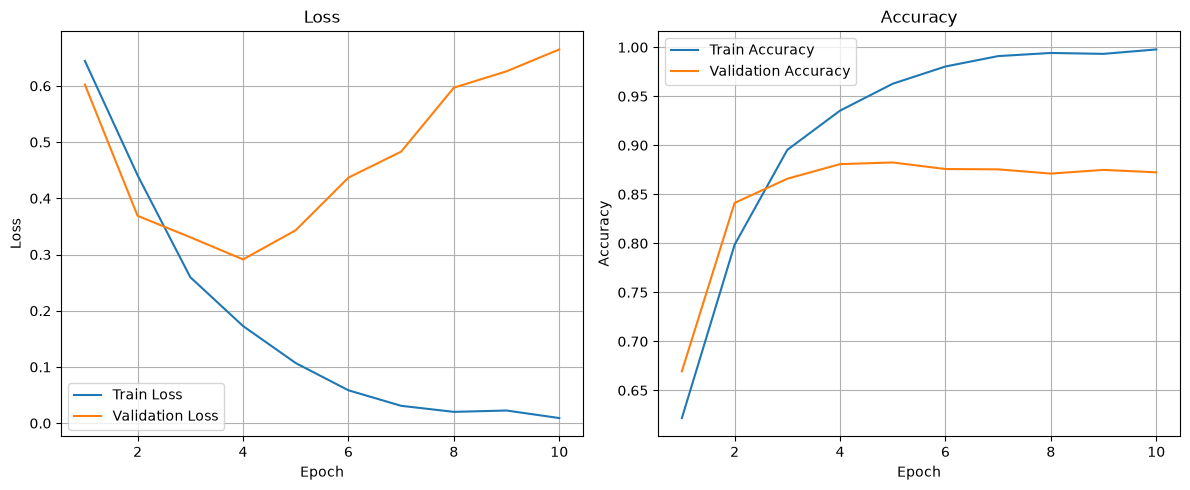


词级 Embedding+LSTM - Val Loss: 0.6648, Val Accuracy: 0.8724


In [142]:
word_lstm_loss, word_lstm_acc = train_single_model(
    lstm_model_word, train_loader_word_recurrent, test_loader_word_recurrent, "词级 Embedding+LSTM"
)  # 词级 LSTM 模型

## 23. BPE 三模型 —— 实例化、前向验证与参数量统计

### BPE 三模型实例化（单层单向，与词级同构，仅词表变小）

In [143]:
pooling_model_bpe = PoolingSentimentClassifier(vocab_size=vocab_size_bpe, embed_dim=128, padding_idx=padding_idx)  # BPE 池化模型
rnn_model_bpe = RNNSentimentClassifier(
    vocab_size=vocab_size_bpe, embed_dim=128, padding_idx=padding_idx, rnn_layers=1, bidirectional=False  # BPE RNN
)
lstm_model_bpe = LSTMSentimentClassifier(
    vocab_size=vocab_size_bpe, embed_dim=128, padding_idx=padding_idx, lstm_layers=1, bidirectional=False  # BPE LSTM
)

In [144]:
# 打印 BPE 模型结构（以 LSTM 为例），与词级对比：Embedding 表从 20000 行减到 8298 行
print("\n========== BPE Embedding + LSTM 结构 ==========")
print(lstm_model_bpe)  # Embedding(8298, 128) —— BPE 词表更小，Embedding 参数量省一半


========== BPE Embedding + LSTM 结构 ==========
LSTMSentimentClassifier(
  (embedding): Embedding(8298, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


### BPE 前向传播验证

In [145]:
dummy_input_bpe = torch.randint(0, vocab_size_bpe, (batch_size, seq_len))  # BPE 词表范围内的随机 ID
print("\n========== BPE 前向传播验证 ==========")
print(f"dummy_input.shape: {dummy_input_bpe.shape}")  # torch.Size([4, 10])
print(f"BPE 池化输出 shape: {pooling_model_bpe(dummy_input_bpe).shape}")  # torch.Size([4, 1])
print(f"BPE RNN  输出 shape: {rnn_model_bpe(dummy_input_bpe).shape}")  # torch.Size([4, 1])
print(f"BPE LSTM 输出 shape: {lstm_model_bpe(dummy_input_bpe).shape}")  # torch.Size([4, 1])


========== BPE 前向传播验证 ==========
dummy_input.shape: torch.Size([4, 10])
BPE 池化输出 shape: torch.Size([4, 1])
BPE RNN  输出 shape: torch.Size([4, 1])
BPE LSTM 输出 shape: torch.Size([4, 1])


### BPE 参数量统计

In [146]:
print("\n========== BPE 参数量统计 ==========")
total_params_bpe_pooling = count_parameters(pooling_model_bpe)  # BPE 池化
total_params_bpe_rnn = count_parameters(rnn_model_bpe)  # BPE RNN
total_params_bpe_lstm = count_parameters(lstm_model_bpe)  # BPE LSTM
print(f"BPE 池化可训练参数总数: {total_params_bpe_pooling:,}")  # 约 1,062,273
print(f"BPE RNN  可训练参数总数: {total_params_bpe_rnn:,}")  # 约 1,161,217
print(f"BPE LSTM 可训练参数总数: {total_params_bpe_lstm:,}")  # 约 1,457,665


========== BPE 参数量统计 ==========
BPE 池化可训练参数总数: 1,062,273
BPE RNN  可训练参数总数: 1,161,217
BPE LSTM 可训练参数总数: 1,457,665


## 24. 训练 BPE 三个模型并绘制训练曲线
BPE（分词方式二）数据来自 train_texts_bpe / test_texts_bpe，
池化模型用 PAD 后置 loader，RNN/LSTM 用 PAD 前置 loader。


========== 开始训练 BPE Embedding+平均池化 (epochs=10) ==========
Epoch 1/10: Train Loss=0.6324 | Train Acc=0.6969 | Val Loss=0.5390 | Val Acc=0.7875
Epoch 2/10: Train Loss=0.4401 | Train Acc=0.8387 | Val Loss=0.4029 | Val Acc=0.8441
Epoch 3/10: Train Loss=0.3373 | Train Acc=0.8764 | Val Loss=0.3540 | Val Acc=0.8610
Epoch 4/10: Train Loss=0.2874 | Train Acc=0.8935 | Val Loss=0.3322 | Val Acc=0.8664
Epoch 5/10: Train Loss=0.2554 | Train Acc=0.9065 | Val Loss=0.3219 | Val Acc=0.8701
Epoch 6/10: Train Loss=0.2318 | Train Acc=0.9158 | Val Loss=0.3195 | Val Acc=0.8715
Epoch 7/10: Train Loss=0.2134 | Train Acc=0.9233 | Val Loss=0.3186 | Val Acc=0.8722
Epoch 8/10: Train Loss=0.1977 | Train Acc=0.9283 | Val Loss=0.3214 | Val Acc=0.8725
Epoch 9/10: Train Loss=0.1847 | Train Acc=0.9341 | Val Loss=0.3268 | Val Acc=0.8712
Epoch 10/10: Train Loss=0.1733 | Train Acc=0.9380 | Val Loss=0.3334 | Val Acc=0.8705


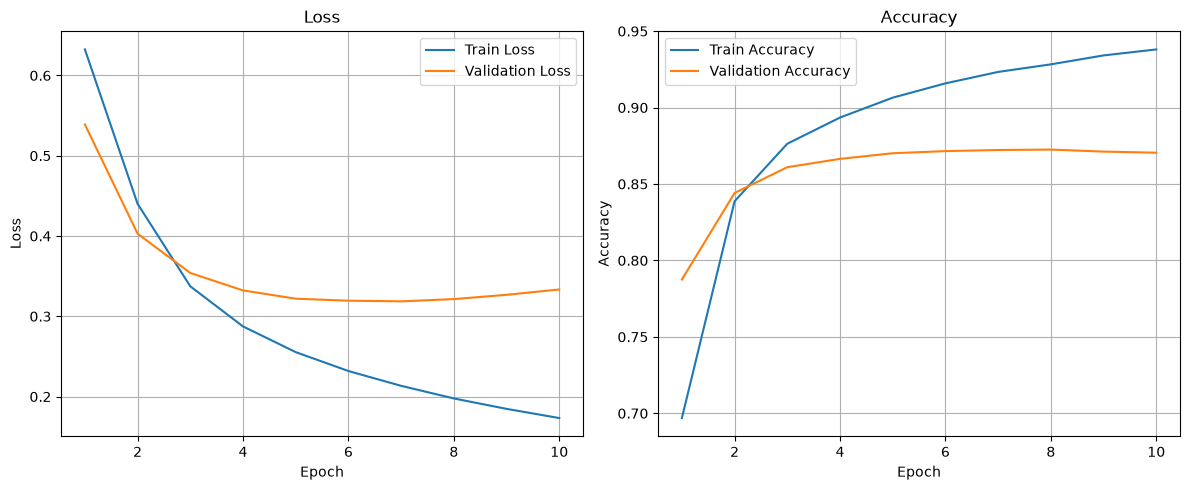


BPE Embedding+平均池化 - Val Loss: 0.3334, Val Accuracy: 0.8705


In [147]:
bpe_pooling_loss, bpe_pooling_acc = train_single_model(
    pooling_model_bpe, train_loader_bpe_pooling, test_loader_bpe_pooling, "BPE Embedding+平均池化"
)  # BPE 池化模型


========== 开始训练 BPE Embedding+RNN (epochs=10) ==========
Epoch 1/10: Train Loss=0.6918 | Train Acc=0.5388 | Val Loss=0.6752 | Val Acc=0.5759
Epoch 2/10: Train Loss=0.6916 | Train Acc=0.5261 | Val Loss=0.6939 | Val Acc=0.4872
Epoch 3/10: Train Loss=0.6969 | Train Acc=0.5133 | Val Loss=0.6892 | Val Acc=0.5370
Epoch 4/10: Train Loss=0.6807 | Train Acc=0.5698 | Val Loss=0.6728 | Val Acc=0.5708
Epoch 5/10: Train Loss=0.6447 | Train Acc=0.6330 | Val Loss=0.6629 | Val Acc=0.6040
Epoch 6/10: Train Loss=0.5968 | Train Acc=0.6849 | Val Loss=0.6843 | Val Acc=0.6393
Epoch 7/10: Train Loss=0.5677 | Train Acc=0.7131 | Val Loss=0.6504 | Val Acc=0.6371
Epoch 8/10: Train Loss=0.5322 | Train Acc=0.7492 | Val Loss=0.6296 | Val Acc=0.6778
Epoch 9/10: Train Loss=0.5038 | Train Acc=0.7681 | Val Loss=0.6557 | Val Acc=0.6772
Epoch 10/10: Train Loss=0.4817 | Train Acc=0.7854 | Val Loss=0.6198 | Val Acc=0.6890


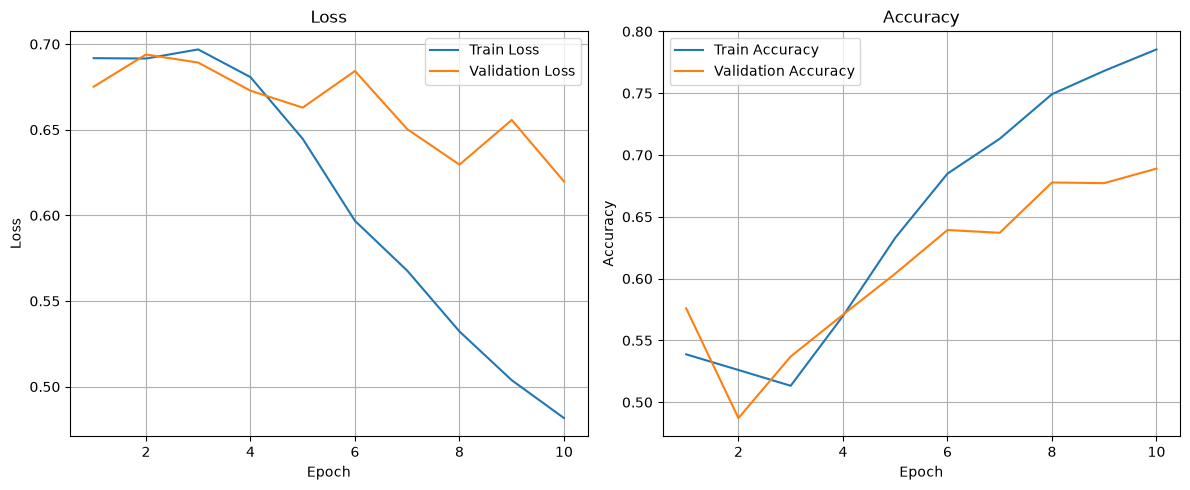


BPE Embedding+RNN - Val Loss: 0.6198, Val Accuracy: 0.6890


In [148]:
bpe_rnn_loss, bpe_rnn_acc = train_single_model(
    rnn_model_bpe, train_loader_bpe_recurrent, test_loader_bpe_recurrent, "BPE Embedding+RNN"
)  # BPE RNN 模型


========== 开始训练 BPE Embedding+LSTM (epochs=10) ==========
Epoch 1/10: Train Loss=0.6597 | Train Acc=0.5918 | Val Loss=0.6063 | Val Acc=0.6684
Epoch 2/10: Train Loss=0.5754 | Train Acc=0.7007 | Val Loss=0.5911 | Val Acc=0.6803
Epoch 3/10: Train Loss=0.4530 | Train Acc=0.7905 | Val Loss=0.4313 | Val Acc=0.8005
Epoch 4/10: Train Loss=0.3267 | Train Acc=0.8618 | Val Loss=0.3549 | Val Acc=0.8504
Epoch 5/10: Train Loss=0.2299 | Train Acc=0.9093 | Val Loss=0.3477 | Val Acc=0.8606
Epoch 6/10: Train Loss=0.1561 | Train Acc=0.9434 | Val Loss=0.4050 | Val Acc=0.8459
Epoch 7/10: Train Loss=0.0894 | Train Acc=0.9692 | Val Loss=0.4914 | Val Acc=0.8507
Epoch 8/10: Train Loss=0.0462 | Train Acc=0.9865 | Val Loss=0.5775 | Val Acc=0.8388
Epoch 9/10: Train Loss=0.0330 | Train Acc=0.9901 | Val Loss=0.6276 | Val Acc=0.8558
Epoch 10/10: Train Loss=0.0363 | Train Acc=0.9890 | Val Loss=0.7082 | Val Acc=0.8504


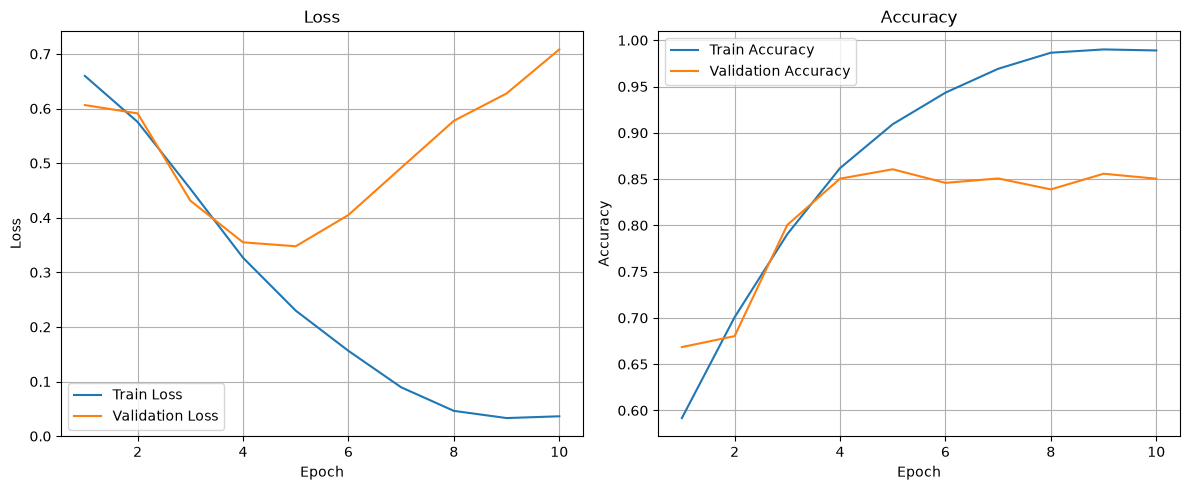


BPE Embedding+LSTM - Val Loss: 0.7082, Val Accuracy: 0.8504


In [149]:
bpe_lstm_loss, bpe_lstm_acc = train_single_model(
    lstm_model_bpe, train_loader_bpe_recurrent, test_loader_bpe_recurrent, "BPE Embedding+LSTM"
)  # BPE LSTM 模型

## 25. 六模型对比总结（分词方式 × 文本表示）

### 词级（分词方式一）指标

In [150]:
print(f"\n--- 分词方式一：词级（正则清洗 + Counter 词频，词表 {vocab_size_word}） ---")
print(f"  Embedding+平均池化: 参数量 {total_params_word_pooling:,}, Val Acc = {word_pooling_acc:.4f}")  # 词级池化
print(f"  Embedding+RNN:     参数量 {total_params_word_rnn:,}, Val Acc = {word_rnn_acc:.4f}")  # 词级 RNN
print(f"  Embedding+LSTM:    参数量 {total_params_word_lstm:,}, Val Acc = {word_lstm_acc:.4f}")  # 词级 LSTM


--- 分词方式一：词级（正则清洗 + Counter 词频，词表 20000） ---
  Embedding+平均池化: 参数量 2,560,129, Val Acc = 0.8867
  Embedding+RNN:     参数量 2,659,073, Val Acc = 0.7145
  Embedding+LSTM:    参数量 2,955,521, Val Acc = 0.8724


### BPE（分词方式二）指标

In [151]:
print(f"\n--- 分词方式二：BPE 子词（subword-nmt，词表 {vocab_size_bpe}） ---")
print(f"  Embedding+平均池化: 参数量 {total_params_bpe_pooling:,}, Val Acc = {bpe_pooling_acc:.4f}")  # BPE 池化
print(f"  Embedding+RNN:     参数量 {total_params_bpe_rnn:,}, Val Acc = {bpe_rnn_acc:.4f}")  # BPE RNN
print(f"  Embedding+LSTM:    参数量 {total_params_bpe_lstm:,}, Val Acc = {bpe_lstm_acc:.4f}")  # BPE LSTM


--- 分词方式二：BPE 子词（subword-nmt，词表 8298） ---
  Embedding+平均池化: 参数量 1,062,273, Val Acc = 0.8705
  Embedding+RNN:     参数量 1,161,217, Val Acc = 0.6890
  Embedding+LSTM:    参数量 1,457,665, Val Acc = 0.8504


### 纵向对比：分词方式

In [152]:
print(f"\n纵向对比（分词方式维度）:")
print(f"  ─────────────────────────────────────────────────────────────────────")
print(f"  分词方式      词表规模      Embedding 参数量    OOV 处理")
print(f"  ─────────────────────────────────────────────────────────────────────")
print(f"  词级          20000        约 2.56M            词典外单词→<OOV>")
print(f"  BPE 子词      约 8300      约 1.06M            任意词拆成已见子词，几乎无 OOV")
print(f"  ─────────────────────────────────────────────────────────────────────")
print(f"  关键差异:")
print(f"    - BPE 词表更小，Embedding 参数量约为词级的一半，模型更轻")
print(f"    - 词级把词典外的词一律映射为 <OOV>；BPE 用子词组合表示未登录词，")
print(f"      能覆盖专有名词、拼写变体等，缓解 OOV 问题")
print(f"    - 一条影评的子词数通常略多于单词数（整词被拆分），序列长度略长")


纵向对比（分词方式维度）:
  ─────────────────────────────────────────────────────────────────────
  分词方式      词表规模      Embedding 参数量    OOV 处理
  ─────────────────────────────────────────────────────────────────────
  词级          20000        约 2.56M            词典外单词→<OOV>
  BPE 子词      约 8300      约 1.06M            任意词拆成已见子词，几乎无 OOV
  ─────────────────────────────────────────────────────────────────────
  关键差异:
    - BPE 词表更小，Embedding 参数量约为词级的一半，模型更轻
    - 词级把词典外的词一律映射为 <OOV>；BPE 用子词组合表示未登录词，
      能覆盖专有名词、拼写变体等，缓解 OOV 问题
    - 一条影评的子词数通常略多于单词数（整词被拆分），序列长度略长


### 横向对比：文本表示

In [153]:
print(f"\n横向对比（文本表示维度）:")
print(f"  ─────────────────────────────────────────────────────────────────────")
print(f"  模型          是否建模顺序   padding位置     最后一步含义")
print(f"  ─────────────────────────────────────────────────────────────────────")
print(f"  池化模型      否 词袋式      句尾（默认）     平均所有 token 向量")
print(f"  RNN 模型      是 序列建模     句首（前置）     最后一个 token 后的隐藏状态")
print(f"  LSTM 模型     是 序列建模     句首（前置）     最后一个 token 后的隐藏状态（含细胞状态）")
print(f"  ─────────────────────────────────────────────────────────────────────")
print(f"  关键差异:")
print(f"    - 池化模型把整句向量求平均，忽略 token 顺序，等价于词袋/子词袋模型")
print(f"    - RNN 模型按顺序读完整个序列，最后一步隐藏状态浓缩了整句的上下文信息")
print(f"    - LSTM 比 vanilla RNN 多一个细胞状态 c_t（长期记忆），靠门控决定记住/遗忘信息，")
print(f"      缓解梯度消失，长序列上通常比 vanilla RNN 更稳定")
print(f"    - 三种文本表示在同一种分词下参数量接近（仅差循环层权重），可公平对比")
print(f"    - padding 前置（padding_first=True）是为循环模型服务的: 句尾 PAD 会污染最后一步")
print(f"    - nn.RNN / nn.LSTM / nn.GRU 接口一致；LSTM 前向多返回一个细胞状态 cn")
print(f"    - 双向/多层是循环模型的扩展方向: 双向翻倍隐藏维度，多层纵向堆叠加深表征能力")


横向对比（文本表示维度）:
  ─────────────────────────────────────────────────────────────────────
  模型          是否建模顺序   padding位置     最后一步含义
  ─────────────────────────────────────────────────────────────────────
  池化模型      否 词袋式      句尾（默认）     平均所有 token 向量
  RNN 模型      是 序列建模     句首（前置）     最后一个 token 后的隐藏状态
  LSTM 模型     是 序列建模     句首（前置）     最后一个 token 后的隐藏状态（含细胞状态）
  ─────────────────────────────────────────────────────────────────────
  关键差异:
    - 池化模型把整句向量求平均，忽略 token 顺序，等价于词袋/子词袋模型
    - RNN 模型按顺序读完整个序列，最后一步隐藏状态浓缩了整句的上下文信息
    - LSTM 比 vanilla RNN 多一个细胞状态 c_t（长期记忆），靠门控决定记住/遗忘信息，
      缓解梯度消失，长序列上通常比 vanilla RNN 更稳定
    - 三种文本表示在同一种分词下参数量接近（仅差循环层权重），可公平对比
    - padding 前置（padding_first=True）是为循环模型服务的: 句尾 PAD 会污染最后一步
    - nn.RNN / nn.LSTM / nn.GRU 接口一致；LSTM 前向多返回一个细胞状态 cn
    - 双向/多层是循环模型的扩展方向: 双向翻倍隐藏维度，多层纵向堆叠加深表征能力
